# Project: Marketing Expenses Optimization. Ticket Selling App Analysis




## Project Description

You are analyzing data from a ticket selling app to help optimize marketing expenses and advise marketing experts on how much money to invest and where. The dataset includes user visits, purchase orders, and marketing costs. The goal of this analysis is to gain insights into user behavior, sales trends, and marketing performance.

## Metrics Explanation

### DAU, WAU, MAU
  - **Daily Active Users (DAU)**: The number of unique users who use the app in a single day.
  - **Weekly Active Users (WAU)**: The number of unique users who use the app within a week.
  - **Monthly Active Users (MAU)**: The number of unique users who use the app in a month.

### CAC (Customer Acquisition Cost)
  - **CAC**: The total marketing cost divided by the number of customers acquired during a specific period. It shows how much it costs to acquire one customer.

### LTV (Lifetime Value)
  - **LTV**: The projected revenue that a customer will generate over the entire duration of their relationship with the business.

### ROI (Return on Investment)
  - **ROI**: A measure of the profitability of marketing investments, calculated as the ratio of the revenue (LTV) to the cost (CAC).

### ROMI (Return on Marketing Investment)
  - **ROMI**: The return on investment specifically from marketing efforts, showing how effective each source is in generating revenue relative to its costs.

## Column Descriptions

**Visits Data**:
- `Device`: Type of device used (e.g., touch, desktop).
- `End Ts`: The end timestamp of the session.
- `Source Id`: The source of the traffic (e.g., referral or direct).
- `Start Ts`: The start timestamp of the session.
- `Uid`: Unique identifier for users.

**Orders Data**:
- `Buy Ts`: Timestamp when the purchase was made.
- `Revenue`: The revenue generated from each purchase.
- `Uid`: Unique identifier for users.

**Expenses Data**:
- `source_id`: Identifier for the marketing source.
- `dt`: Date of expense.
- `costs`: The marketing expense incurred.

# Step 0. Import libraries, load data

In [ ]:
import pandas as pd
import numpy as np
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px


In [ ]:
def load_csv(filename, backup_path):
    try:
        # Try to load from the current working directory
        return pd.read_csv(filename)
    except:
        # Fallback to the backup path (in /content/sample_data)
        return pd.read_csv(backup_path)

# Load files using the helper function
visits = load_csv('visits_log_us.csv', '/content/sample_data/visits_log.csv')
orders = load_csv('orders_log_us.csv', '/content/sample_data/orders_log.csv')
costs = load_csv('costs_us.csv', '/content/sample_data/costs.csv')


# Step 1. Data Overview¶

## 1.1 visits_log.csv

In [ ]:
visits.sample(5)

,Device,End Ts,Source Id,Start Ts,Uid
215517,desktop,2018-02-02 00:48:00,3,2018-02-02 00:43:00,6843418812504165819
82245,touch,2017-10-12 12:14:00,3,2017-10-12 12:05:00,4711685265406286015
303026,touch,2017-06-06 00:05:00,10,2017-06-06 00:05:00,4160963968051867425
170956,desktop,2018-01-24 18:08:00,4,2018-01-24 17:55:00,10841774296680552166
129911,desktop,2018-01-18 11:15:00,5,2018-01-18 11:07:00,6563017280441876616


In [ ]:
visits.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 359400 entries, 0 to 359399
Data columns (total 5 columns):
 #   Column     Non-Null Count   Dtype 
---  ------     --------------   ----- 
 0   Device     359400 non-null  object
 1   End Ts     359400 non-null  object
 2   Source Id  359400 non-null  int64 
 3   Start Ts   359400 non-null  object
 4   Uid        359400 non-null  uint64
dtypes: int64(1), object(3), uint64(1)
memory usage: 13.7+ MB


In [ ]:
visits.duplicated().sum()

0

In [ ]:
visits.isna().sum()

,0
Device,0
End Ts,0
Source Id,0
Start Ts,0
Uid,0


**Description**:
- we have 359400 rows 5 columns of data,initial memory usage 13.7+ MB(can be optimized)
- no duplicates, no missing values
- column names to be cleaned(lowercase, replace ' ' with '_')
- data types to be addressed: End Ts, Start Ts should be datetime(not object), device > to category, Source Id > to int8 (for memory optimisation)

## 1.2 orders_log.csv

In [ ]:
orders.sample(5)

,Buy Ts,Revenue,Uid
14210,2017-10-23 18:09:00,1.95,10076108931468800115
20685,2017-11-28 14:36:00,1.10,18295771519195086861
27195,2017-12-30 15:37:00,4.28,348238000252671115
12137,2017-10-11 11:33:00,4.58,13507729055670128212
23438,2017-12-11 20:59:00,0.06,13589776077963509480


In [ ]:
orders.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 50415 entries, 0 to 50414
Data columns (total 3 columns):
 #   Column   Non-Null Count  Dtype  
---  ------   --------------  -----  
 0   Buy Ts   50415 non-null  object 
 1   Revenue  50415 non-null  float64
 2   Uid      50415 non-null  uint64 
dtypes: float64(1), object(1), uint64(1)
memory usage: 1.2+ MB


In [ ]:
orders.isna().sum()

,0
Buy Ts,0
Revenue,0
Uid,0


In [ ]:
orders.duplicated().sum()

0

**Description**:
- we have 50415 rows 3 columns of data,initial memory usage 1.2+ MB (can be optimized)
- no duplicates, no missing values
- column names to be cleaned(lowercase, replace ' ' with '_')
- data types to be addressed: Buy Ts object > to datetime. Other cols are ok.

## 1.3 costs.csv

In [ ]:
costs.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2542 entries, 0 to 2541
Data columns (total 3 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   source_id  2542 non-null   int64  
 1   dt         2542 non-null   object 
 2   costs      2542 non-null   float64
dtypes: float64(1), int64(1), object(1)
memory usage: 59.7+ KB


In [ ]:
costs.isna().sum()

,0
source_id,0
dt,0
costs,0


In [ ]:
costs.duplicated().sum()

0

**Description**:
- we have 2542 rows 3 columns of data,initial memory usage 59.7+ KB(can be optimized)
- no duplicates, no missing values
- column names are ok
- data types to be addressed: dt column should be datetime(not object), source_id int64 > to int8 (for memory optimisation)

# Step 2. Data Preparation

## Task 1: Convert column names to lowercase and replace spaces with underscores - for cols in visits and orders


In [ ]:
visits.columns = visits.columns.str.lower().str.replace(' ', '_')
orders.columns = orders.columns.str.lower().str.replace(' ', '_')
print(f'Column names in visits df: {visits.columns}\n'
      f'Column names in orders df: {orders.columns}')

Column names in visits df: Index(['device', 'end_ts', 'source_id', 'start_ts', 'uid'], dtype='object')
Column names in orders df: Index(['buy_ts', 'revenue', 'uid'], dtype='object')


## Task 2: Convert date columns in all tables to datetime format


In [ ]:
visits[['start_ts', 'end_ts']] = visits[['start_ts', 'end_ts']].apply(pd.to_datetime)
orders['buy_ts'] = pd.to_datetime(orders['buy_ts'])
costs['dt'] = pd.to_datetime(costs['dt'])

In [ ]:
# For memory optimization
# Convert 'device' column in visits to category
visits['device'] = visits['device'].astype('category')

# Convert 'source_id' columns in visits and costs to int8
visits['source_id'] = visits['source_id'].astype('int8')
costs['source_id'] = costs['source_id'].astype('int8')


In [ ]:
#check datatypes and memory
print('visits df:')
visits.info()
print('\n')

print('orders df:')
orders.info()
print('\n')

print('costs df:')
costs.info()
print('\n')

visits df:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 359400 entries, 0 to 359399
Data columns (total 5 columns):
 #   Column     Non-Null Count   Dtype         
---  ------     --------------   -----         
 0   device     359400 non-null  category      
 1   end_ts     359400 non-null  datetime64[ns]
 2   source_id  359400 non-null  int8          
 3   start_ts   359400 non-null  datetime64[ns]
 4   uid        359400 non-null  uint64        
dtypes: category(1), datetime64[ns](2), int8(1), uint64(1)
memory usage: 8.9 MB


orders df:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 50415 entries, 0 to 50414
Data columns (total 3 columns):
 #   Column   Non-Null Count  Dtype         
---  ------   --------------  -----         
 0   buy_ts   50415 non-null  datetime64[ns]
 1   revenue  50415 non-null  float64       
 2   uid      50415 non-null  uint64        
dtypes: datetime64[ns](1), float64(1), uint64(1)
memory usage: 1.2 MB


costs df:
<class 'pandas.core.frame.DataFrame

**Description**:
- no missing values, no duplicates in data
- all datatypes are correct
- column names are consistent and lowercase
- memory usage is reduced from 13.7+ to 8.9.MB (visits df), from 1.2+ to 1.2MB(orders df), 59.7 to 42.3 KB (costs df)
- outliers and illogical values to be checked


## Task 3: Clean data


In [ ]:
#inspect categorical values
visits.device.value_counts()


,count
device,
desktop,262567
touch,96833


We have only 2 values 'desctop' and 'touch' - ok

In [ ]:
#inspect source_id in visits and costs - values are numerical but represent categories
visits.source_id.value_counts()

,count
source_id,
4,101794
3,85610
5,66905
2,47626
1,34121
9,13277
10,10025
7,36
6,6


In [ ]:
#find source_id percentage
visits.source_id.value_counts(normalize = True)

,proportion
source_id,
4,0.283233
3,0.238203
5,0.186157
2,0.132515
1,0.094939
9,0.036942
10,0.027894
7,0.000100
6,0.000017


The most commonn value among 9 sources is 4 (more than 28%). The difference between sources 6,7 and others is too big, they can't be compared. Sources 7,6 constitute only 0.01 - 0.0017% of data in the column and can be regarded as outliers.

In [ ]:
costs.source_id.value_counts()

,count
source_id,
5,364
1,363
2,363
3,363
4,363
9,363
10,363


Only 7 of 9 sources are present in costs table, and they are equally distributed. Since these are the same sourses as in visits table and sources 6,7 are absent in costs, and they are outliers in visits(too rare), let's drop them. We lose just about 0.01 % of rows.

In [ ]:
# Drop rows where 'source_id' is 6 or 7
visits = visits[~visits['source_id'].isin([6, 7])]
visits.shape


(359358, 5)

In [ ]:
#compare datetime cols in the tables
visits[['start_ts', 'end_ts']].describe()

,start_ts,end_ts
count,359358,359358
mean,2017-12-18 06:21:22.849080320,2017-12-18 06:32:05.866273024
min,2017-06-01 00:01:00,2017-06-01 00:02:00
25%,2017-10-15 09:48:15,2017-10-15 10:00:30
50%,2017-12-18 18:50:00,2017-12-18 19:01:30
75%,2018-02-28 09:59:45,2018-02-28 10:10:45
max,2018-05-31 23:59:00,2018-06-01 01:26:00


In [ ]:
orders.buy_ts.describe()

,buy_ts
count,50415
mean,2017-12-20 05:14:24.846176768
min,2017-06-01 00:10:00
25%,2017-10-13 17:28:00
50%,2017-12-21 14:12:00
75%,2018-03-02 16:10:00
max,2018-06-01 00:02:00


In [ ]:
costs.dt.describe()

,dt
count,2542
mean,2017-11-29 09:04:57.403619072
min,2017-06-01 00:00:00
25%,2017-08-30 00:00:00
50%,2017-11-29 00:00:00
75%,2018-02-28 00:00:00
max,2018-05-31 00:00:00


The tables are supposed to be consistent and have the same data range: from 2017-06-01 to 2018-05-31, but in visits.end_ts and in orders.buy_ts there are dates for june 2018. For accurate analysis we should drop them.

In [ ]:
visits=visits[visits['end_ts'] < '2018-06-01']
visits.end_ts.describe()

,end_ts
count,359346
mean,2017-12-18 06:24:10.556155136
min,2017-06-01 00:02:00
25%,2017-10-15 09:46:15
50%,2017-12-18 18:58:30
75%,2018-02-28 10:05:45
max,2018-05-31 23:59:00


In [ ]:
orders=orders[orders['buy_ts']  < '2018-06-01']
orders.describe()

,buy_ts,revenue,uid
count,50414,50414.000000,5.041400e+04
mean,2017-12-20 05:09:45.867021312,4.999678,9.098339e+18
min,2017-06-01 00:10:00,0.000000,3.135781e+14
25%,2017-10-13 17:27:00,1.220000,4.534221e+18
50%,2017-12-21 14:08:00,2.500000,9.102683e+18
75%,2018-03-02 16:09:30,4.890000,1.368294e+19
max,2018-05-31 23:56:00,2633.280000,1.844617e+19
std,NaN,21.818574,5.285642e+18


Now datetime cols in three tables are consistent - we have data for 1 year from 2017-06-01 to 2018-05-31.

We also see 0 as min revenue values, which is impossible.

In [ ]:
#find rows with 0 revenues:
zero_rev=orders[orders['revenue']==0]
zero_rev.head()



,buy_ts,revenue,uid
1802,2017-06-22 18:19:00,0.0,17030528792926543083
2787,2017-07-07 15:54:00,0.0,10281425020415612933
4783,2017-08-02 14:54:00,0.0,184148767273119549
5095,2017-08-09 14:48:00,0.0,5603453646174104178
5863,2017-08-23 13:43:00,0.0,5603453646174104178


In [ ]:
zero_rev.shape

(51, 3)

In [ ]:
zero_rev.uid.nunique()

23

So, we have 51 rows with 0 revenues from different users. Maybe the users decided to cancel the order or there was a technical issue, so actually there were no order. As we need real orders for analysis, let's drop rows with zero revenues from orders df.

In [ ]:
orders = orders[orders['revenue'] != 0]
orders.shape

(50363, 3)

All other numerical columns are ok.

## Task 4: (Up to you) Add columns with date, week, month values to the tables - they will be necessary for analysis.

In [ ]:
visits['date']=visits['start_ts'].dt.to_period('D').dt.to_timestamp()
visits['week'] = visits['start_ts'].dt.to_period('W').dt.to_timestamp()
visits['month'] = visits['start_ts'].dt.to_period('M').dt.to_timestamp()
visits['dow'] = visits['date'].dt.dayofweek
orders['date']=orders['buy_ts'].dt.to_period('D').dt.to_timestamp()
orders['month'] = orders['buy_ts'].dt.to_period('M').dt.to_timestamp()
costs['month'] = costs['dt'].dt.to_period('M').dt.to_timestamp()

Plot data to get a general representation of feature relations

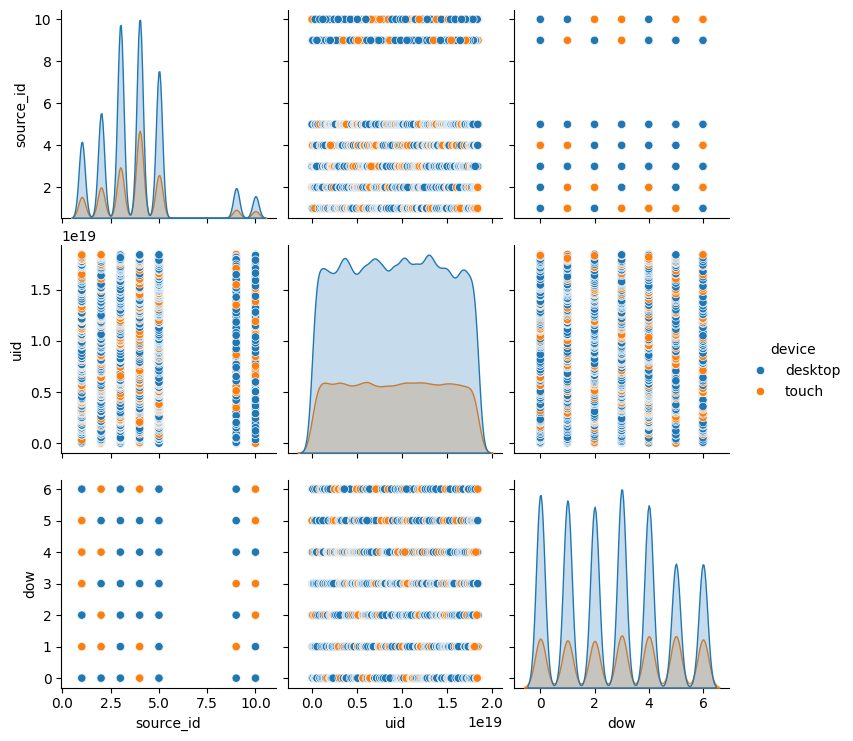

In [ ]:
sns.pairplot(visits,hue='device');

In [ ]:
#check data after all changes
print('visits df:')
visits.info()
print('\n')

print('orders df:')
orders.info()
print('\n')

print('costs df:')
costs.info()
print('\n')

visits df:
<class 'pandas.core.frame.DataFrame'>
Index: 359346 entries, 0 to 359399
Data columns (total 9 columns):
 #   Column     Non-Null Count   Dtype         
---  ------     --------------   -----         
 0   device     359346 non-null  category      
 1   end_ts     359346 non-null  datetime64[ns]
 2   source_id  359346 non-null  int8          
 3   start_ts   359346 non-null  datetime64[ns]
 4   uid        359346 non-null  uint64        
 5   date       359346 non-null  datetime64[ns]
 6   week       359346 non-null  datetime64[ns]
 7   month      359346 non-null  datetime64[ns]
 8   dow        359346 non-null  int32         
dtypes: category(1), datetime64[ns](5), int32(1), int8(1), uint64(1)
memory usage: 21.2 MB


orders df:
<class 'pandas.core.frame.DataFrame'>
Index: 50363 entries, 0 to 50413
Data columns (total 5 columns):
 #   Column   Non-Null Count  Dtype         
---  ------   --------------  -----         
 0   buy_ts   50363 non-null  datetime64[ns]
 1   revenue  

## **Final data description**:
- visits df: 359346 rows 9 cols
  orders df: 50363 rows 5 cols
  costs df: 2541 rows 4 cols
- no missing values, no duplicates in data
- all datatypes are correct, memory usage optimized
- column names are consistent and lowercase
- rows with sources 6,7 (which are present only in visits df and not in costs df) are considered outliers and dropped (0.01% of data)
- 13 rows with dates out of range 2017-06-01 - 2018-05-31 in tables visits and orders are dropped, so datetime cols in all three tables are consistent
- 51 rows with 0 revenues were dropped from orders df
- no illogical values, no outliers (but can be found in later steps of analysis).

# Step 3. User Metrics Calculations

# DAU, MAU, WAU

## Task 5: Calculate Daily Active Users (DAU) (and plot)
Daily Active Users (DAU): The number of unique users who use the app in a single day.


In [ ]:
dau=visits.groupby('date').uid.nunique().reset_index(name='dau')
dau.head()

,date,dau
0,2017-06-01,605
1,2017-06-02,608
2,2017-06-03,445
3,2017-06-04,476
4,2017-06-05,820


In [ ]:
dau.describe()

,date,dau
count,364,364.000000
mean,2017-11-29 15:57:21.758241792,907.859890
min,2017-06-01 00:00:00,1.000000
25%,2017-08-30 18:00:00,594.000000
50%,2017-11-29 12:00:00,921.000000
75%,2018-02-28 06:00:00,1173.000000
max,2018-05-31 00:00:00,3319.000000
std,NaN,370.390747


DAU varies a lot from 1 to 3319 unique users a day, with close average and median values(908, 921).

In [ ]:
import plotly.io as pio
pio.renderers.default = 'colab'

# Plotting your graph
fig = px.line(dau, x="date", y="dau", title='DAU')

# Adding reference line with average DAU over time
fig.add_hline(y=dau['dau'].mean(), line_dash="dash", line_color="purple", annotation_text="average DAU",
             annotation_position="top left")

fig.show()

For nearly half a year(October - March) DAU is above average with the peak value on Nov.24 (BLACK FRIDAY?), before the winter holidays(Cristmass, New Year). There's also a peak on May 31(end of the scool year?), a rise on March 25 then drop down to min values on March 31 (maybe after spring holidays or some technical issues with the app?). By July 17 the line suddenly rises and falls - maybe there was some add compain or another factor influensed it. We can also see small regular fluctuations during the week.

Let's check if number of users varies with day of the week.

In [ ]:
#group users by day of the week
dow_visits = visits.groupby(['dow'])['uid'].count().reset_index()
dow_visits

,dow,uid
0,0,56295
1,1,54515
2,2,52946
3,3,58503
4,4,54576
5,5,41751
6,6,40760


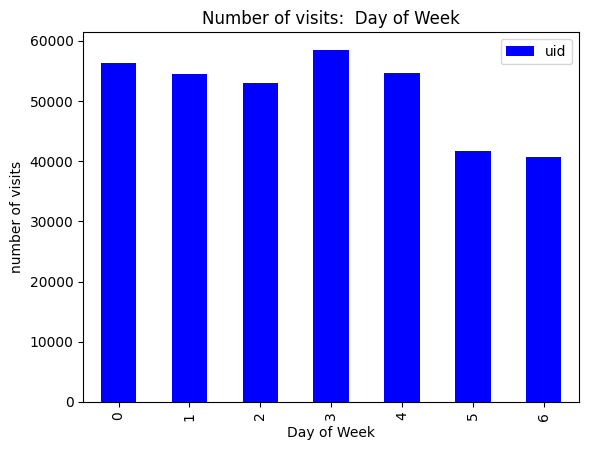

In [ ]:
dow_visits.plot(kind='bar', x='dow', y='uid', color='blue')
plt.xlabel('Day of Week')
plt.ylabel('number of visits')
plt.title('Number of visits:  Day of Week')
plt.show()

So, people open the app most often on Thursday, then on Monday, while min number of visits is on Saturday and Sunday - on weekends users are less active. These fluctuations constitute a certain week cycle.

## Task 6: Calculate Weekly Active Users (WAU) (and plot)
Weekly Active Users (WAU): The number of unique users who use the app within a week.

In [ ]:
wau=visits.groupby('week').uid.nunique().reset_index(name = 'wau')
wau.head()

,week,wau
0,2017-05-29,2021
1,2017-06-05,4128
2,2017-06-12,2812
3,2017-06-19,2877
4,2017-06-26,3063


In [ ]:
wau.describe()

,week,wau
count,53,53.000000
mean,2017-11-27 00:00:00,5715.377358
min,2017-05-29 00:00:00,2021.000000
25%,2017-08-28 00:00:00,4128.000000
50%,2017-11-27 00:00:00,5740.000000
75%,2018-02-26 00:00:00,7400.000000
max,2018-05-28 00:00:00,10586.000000
std,NaN,2049.684856


WAU varies from 2021 to 10586 unique users per week, the mean is 5716 (the median is 5740 - a little greater).

In [ ]:
fig = px.line(wau,x="week", y="wau",title='WAU')
#adding reference line with average WAU over time
fig.add_hline(y=wau['wau'].mean(),line_dash="dash", line_color="purple", annotation_text="average WAU",
             annotation_position="top left")
fig.show()

Again we see max WAU in the end of november, minor peaks on October 2, at the end of January 29, March 19. min values are in July-August weeks. As a whole WAU is below average from the end of March till the middle of September.

## Task 7: Calculate Monthly Active Users (MAU) (and plot)
Monthly Active Users (MAU): The number of unique users who use the app in a month.

In [ ]:
mau=visits.groupby('month').uid.nunique().reset_index(name = 'mau')
mau

,month,mau
0,2017-06-01,13257
1,2017-07-01,14180
2,2017-08-01,11629
3,2017-09-01,18972
4,2017-10-01,29688
5,2017-11-01,32796
6,2017-12-01,31548
7,2018-01-01,28712
8,2018-02-01,28747
9,2018-03-01,27472


In [ ]:
mau.describe()

,month,mau
count,12,12.000000
mean,2017-11-15 14:00:00,23225.000000
min,2017-06-01 00:00:00,11629.000000
25%,2017-08-24 06:00:00,17774.000000
50%,2017-11-16 00:00:00,24239.500000
75%,2018-02-08 00:00:00,28982.250000
max,2018-05-01 00:00:00,32796.000000
std,NaN,7545.903693


MAU varies from 11629 to 32796 users per month, the mean is 23225.

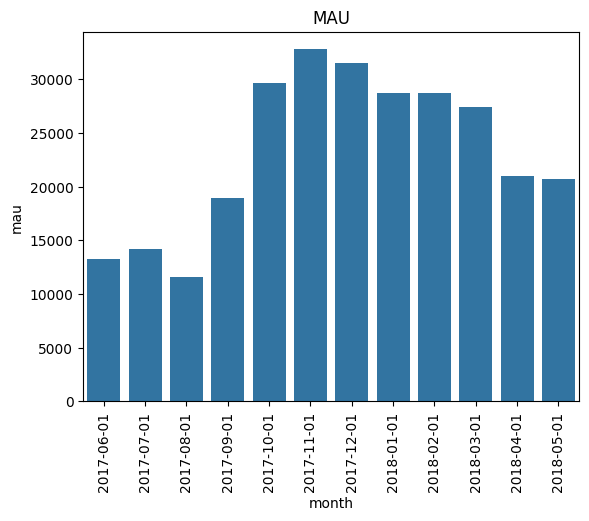

In [ ]:
plot=sns.barplot(data=mau, x="month", y="mau")
plot.set(title="MAU")
plot.tick_params(axis='x', rotation=90)

The plot shows that MAU is rising from August to November (max values are November and December),  then MAU gradually goes dows. The lowest MAU are during summer months - in summer people buy less (min MAU value is in August).

# Session Analysis

## Task 8: Calculate the number of sessions per day and per user
group by date, count uid.


In [ ]:
#group by date, count uid
sessions_day=visits.groupby(['date'])['uid'].count().reset_index(name = 'sessions/day')
sessions_day.head()

,date,sessions/day
0,2017-06-01,664
1,2017-06-02,658
2,2017-06-03,477
3,2017-06-04,510
4,2017-06-05,893


In [ ]:
sessions_day.describe()

,date,sessions/day
count,364,364.000000
mean,2017-11-29 15:57:21.758241792,987.214286
min,2017-06-01 00:00:00,1.000000
25%,2017-08-30 18:00:00,635.500000
50%,2017-11-29 12:00:00,1003.000000
75%,2018-02-28 06:00:00,1280.000000
max,2018-05-31 00:00:00,4042.000000
std,NaN,418.844986


Number of sessions per day varies from 1 to 4042, the mean is 987 (the median is 1003 - there's some right skew).

In [ ]:
fig = px.line(sessions_day,x="date", y="sessions/day",title='Number of Sessions per Day')
#adding reference line with average DAU over time
fig.add_hline(y=sessions_day['sessions/day'].mean(),line_dash="dash", line_color="purple", annotation_text="average sessions_day",
             annotation_position="top left")
fig.show()

Although the range of values  in  'sessions/day' is greater than DAU, the overall picture of distribution of these metrics with peaks and week cycles is pretty similar. If we plot them on the same graph it will be more evident.


In [ ]:
day_dynamics=pd.merge(dau, sessions_day, on='date', how='inner')
day_dynamics.head()

,date,dau,sessions/day
0,2017-06-01,605,664
1,2017-06-02,608,658
2,2017-06-03,445,477
3,2017-06-04,476,510
4,2017-06-05,820,893


In [ ]:
import plotly.graph_objects as go  # Import go

fig = go.Figure()
fig.add_trace(go.Scatter(x=day_dynamics['date'],
                        y=day_dynamics['dau'],
                    mode='lines',
                    name='DAU',line = dict(color='yellow', width=2 )))

fig.add_trace(go.Scatter(x=day_dynamics['date'],
                        y=day_dynamics['sessions/day'],

                    mode='lines',
                    name='sessions',line = dict(color='black', width=2 )))


fig.update_layout(
    showlegend=True,
    plot_bgcolor="grey",
    margin=dict(t=10,l=10,b=10,r=10)
)


fig.show()

Find **average number of sessions per user** by dividing total number of sessions per day by DAU and explore the dynamics.

In [ ]:
day_dynamics['sessions/user'] = day_dynamics['sessions/day']/ day_dynamics['dau']
day_dynamics.head()

,date,dau,sessions/day,sessions/user
0,2017-06-01,605,664,1.097521
1,2017-06-02,608,658,1.082237
2,2017-06-03,445,477,1.071910
3,2017-06-04,476,510,1.071429
4,2017-06-05,820,893,1.089024


In [ ]:
day_dynamics['sessions/user'].describe()

,sessions/user
count,364.000000
mean,1.082168
std,0.020877
min,1.000000
25%,1.070321
50%,1.082488
75%,1.093896
max,1.217837


The variation in 'sessions/user' is much smaller than in DAU or sessions/day, but we expect similar picture of distribution by date. Let's plot it.

In [ ]:
#plot sessions per user by date
fig = px.line(day_dynamics,
              x="date", y="sessions/user",title='Sessions per user')
fig.add_hline(y=day_dynamics['sessions/user'].mean(),line_dash="dash", line_color="purple", annotation_text="average sessions_user",
             annotation_position="top left")
fig.show()

Number of sessions per user varies less, it is normally distributed (with mean = median = 1.08 and std only 0.02) There are regular weekly cycles of ups and downs. Max value is again on Nov 24(Black Friday), smaller peaks on Feb 1, Mar 26, May 31, Jun 7, Jul 17, min on Mar 31.

## Task 9: Calculate the average session length

In [ ]:
#calculate the difference between visit end and stat values
visits['session_length']= visits['end_ts']-visits['start_ts']
visits.session_length.head()

,session_length
0,0 days 00:18:00
1,0 days 00:28:00
2,0 days 00:00:00
3,0 days 00:24:00
4,0 days 00:00:00


In [ ]:
visits.session_length.describe()

,session_length
count,359346
mean,0 days 00:10:42.976384876
std,0 days 00:16:37.044150015
min,-1 days +23:14:00
25%,0 days 00:02:00
50%,0 days 00:05:00
75%,0 days 00:14:00
max,0 days 11:51:00


We got a weird min session_length value -1 day + 23:14:00, which is absolutely impossible. Let's find the row in visits table:

In [ ]:
visits.query('session_length =="-1 days +23:14:00"')

,device,end_ts,source_id,start_ts,uid,date,week,month,dow,session_length
177972,desktop,2018-03-25 03:09:00,9,2018-03-25 03:55:00,4621202742905035453,2018-03-25,2018-03-19,2018-03-01,6,-1 days +23:14:00


Here start_ts is greater than end_ts and give negative session_length - that's an error! What if there is more than 1 such case?


In [ ]:
visits.query('start_ts > end_ts')

,device,end_ts,source_id,start_ts,uid,date,week,month,dow,session_length
4181,desktop,2018-03-25 03:18:00,3,2018-03-25 03:50:00,13092152539246794986,2018-03-25,2018-03-19,2018-03-01,6,-1 days +23:28:00
177972,desktop,2018-03-25 03:09:00,9,2018-03-25 03:55:00,4621202742905035453,2018-03-25,2018-03-19,2018-03-01,6,-1 days +23:14:00


There're only 2 cases, both on the same day almost the same time(at night!), so maybe there were problems with internet connection or some other technical issues. We do not now if start_ts and end_ts just switched places or were recorded incorrectly, so we can't restore them. Let's just exclude the rows from the analysis.


In [ ]:
visits=visits.query('start_ts <= end_ts')
visits.session_length.describe()

,session_length
count,359344
mean,0 days 00:10:42.992987221
std,0 days 00:16:37.021596222
min,0 days 00:00:00
25%,0 days 00:02:00
50%,0 days 00:05:00
75%,0 days 00:14:00
max,0 days 11:51:00


Mean session_length is 10 min 43sec, while median is much lower - only 5 min, so the distribution is right skewed. Let's plot a histogtam. First datatypes should be changed and values turned to minutes as numeric.

In [ ]:
# To get minutes from timedelta divide total duration in seconds by 60
visits['session_length_minutes'] = visits['session_length'].dt.total_seconds() / 60
visits['session_length_minutes'].describe()

,session_length_minutes
count,359344.000000
mean,10.716550
std,16.617027
min,0.000000
25%,2.000000
50%,5.000000
75%,14.000000
max,711.000000


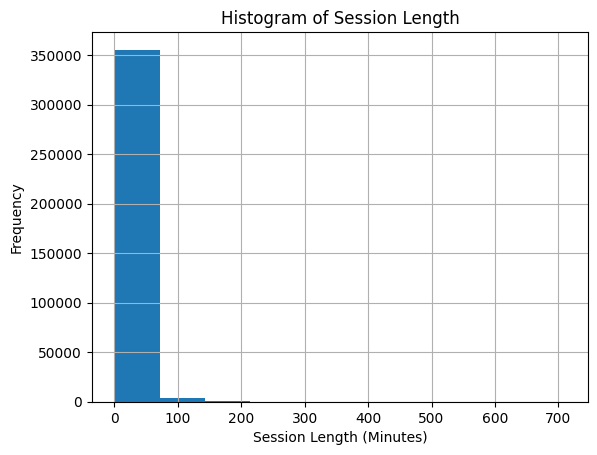

In [ ]:
# Plotting the histogram
visits['session_length_minutes'].hist()

# Adding labels and title
plt.xlabel('Session Length (Minutes)')
plt.ylabel('Frequency')
plt.title('Histogram of Session Length')
plt.show()


There're outliers with length up to 711 min, but 75% of data is below 14 min. Let's 'zoom' the picture.

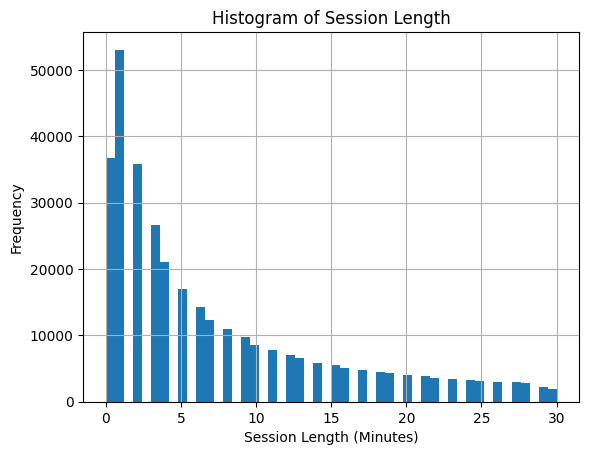

In [ ]:
visits['session_length_minutes'].hist(bins=50, range = (0,30))
plt.xlabel('Session Length (Minutes)')
plt.ylabel('Frequency')
plt.title('Histogram of Session Length')
plt.show()

So, most common sessions last up to 2 mins(25%), and half of all sessions last up to 5 min.

**Calculate outliers** with Z-score and IQR methods

In [ ]:
# Calculate the Z-scores
visits['Z-Score'] = (visits['session_length_minutes'] - visits['session_length_minutes'].mean()) / visits['session_length_minutes'].std()

# Identify outliers where the absolute value of Z-score is greater than 3
outliers_z = visits[np.abs(visits['Z-Score']) > 3]

print("Outliers detected using Z-Score method:")
print(outliers_z)

Outliers detected using Z-Score method:
         device              end_ts  source_id            start_ts  \
15        touch 2018-02-12 20:30:00          2 2018-02-12 19:24:00   
19      desktop 2018-05-17 19:26:00          2 2018-05-17 18:10:00   
201     desktop 2017-06-29 12:19:00          2 2017-06-29 10:40:00   
300     desktop 2018-01-30 16:07:00          3 2018-01-30 15:02:00   
420     desktop 2017-10-09 20:08:00          3 2017-10-09 18:57:00   
...         ...                 ...        ...                 ...   
358388  desktop 2017-10-30 19:47:00          4 2017-10-30 18:44:00   
358399  desktop 2017-07-20 20:08:00          1 2017-07-20 17:31:00   
358424  desktop 2018-01-16 11:08:00          1 2018-01-16 10:01:00   
358433    touch 2017-12-17 16:56:00          2 2017-12-17 15:09:00   
358483    touch 2017-11-24 13:10:00          1 2017-11-24 11:20:00   

                         uid       date       week      month  dow  \
15      18188358787673499603 2018-02-12 2018-02-1

In [ ]:
# Calculate Q1 (25th percentile) and Q3 (75th percentile)
Q1 = visits['session_length_minutes'] .quantile(0.25)
Q3 = visits['session_length_minutes'] .quantile(0.75)

# Calculate IQR
IQR = Q3 - Q1

lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

outliers_iqr = visits[(visits['session_length_minutes']  < lower_bound) | (visits['session_length_minutes']  > upper_bound)]

print(f"Lower_bound: {lower_bound}\n Upper_bound: {upper_bound}\n Outliers detected using IQR method:")
print(outliers_iqr)

Lower_bound: -16.0
 Upper_bound: 32.0
 Outliers detected using IQR method:
         device              end_ts  source_id            start_ts  \
6       desktop 2018-01-30 12:09:00          1 2018-01-30 11:13:00   
15        touch 2018-02-12 20:30:00          2 2018-02-12 19:24:00   
19      desktop 2018-05-17 19:26:00          2 2018-05-17 18:10:00   
44      desktop 2017-12-26 14:39:00          9 2017-12-26 14:00:00   
46      desktop 2017-08-03 12:16:00          9 2017-08-03 11:37:00   
...         ...                 ...        ...                 ...   
358433    touch 2017-12-17 16:56:00          2 2017-12-17 15:09:00   
358436  desktop 2018-04-06 15:51:00          5 2018-04-06 15:16:00   
358483    touch 2017-11-24 13:10:00          1 2017-11-24 11:20:00   
358512  desktop 2018-02-24 23:28:00          3 2018-02-24 22:51:00   
358519  desktop 2018-01-21 16:25:00          1 2018-01-21 15:48:00   

                         uid       date       week      month  dow  \
6        66616

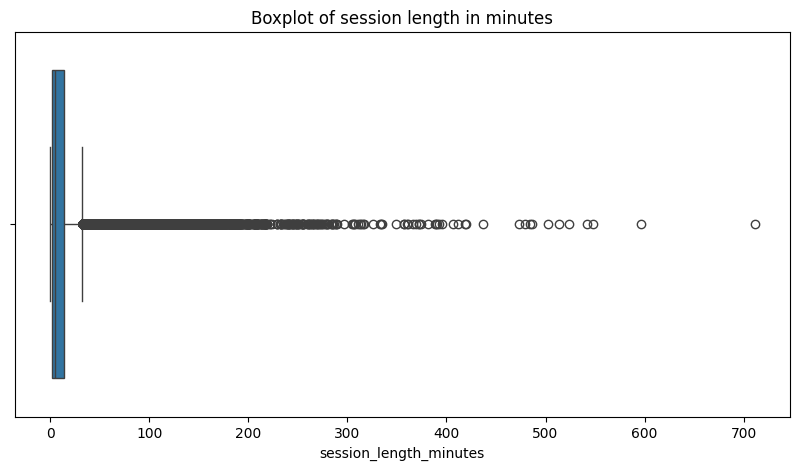

In [ ]:
#plot iqr-outliers with boxplot
plt.figure(figsize=(10, 5))
sns.boxplot(x=visits['session_length_minutes'])
plt.title(f'Boxplot of session length in minutes')
plt.show()


In [ ]:
#compare methods
print(f'Session length outliers by Z-score are {len(outliers_z)} rows - {round(len(outliers_z)/len(visits)*100, 1)}% of sessions')
print(f'Session length outliers by IQR are {len(outliers_iqr)} rows - {round(len(outliers_iqr)/len(visits)*100, 1)}% of sessions')

Session length outliers by Z-score are 6278 rows - 1.7% of sessions
Session length outliers by IQR are 24650 rows - 6.9% of sessions


So, Z-score method detects less outlies than IQR method. Let's filter visits table to exclude iqr_outliers - that is sessions lasting more than 32 min(upper bound = 32 min).

In [ ]:
visits_f = visits[visits['session_length_minutes'] <= 32]
visits_f.info()

<class 'pandas.core.frame.DataFrame'>
Index: 334694 entries, 0 to 359399
Data columns (total 12 columns):
 #   Column                  Non-Null Count   Dtype          
---  ------                  --------------   -----          
 0   device                  334694 non-null  category       
 1   end_ts                  334694 non-null  datetime64[ns] 
 2   source_id               334694 non-null  int8           
 3   start_ts                334694 non-null  datetime64[ns] 
 4   uid                     334694 non-null  uint64         
 5   date                    334694 non-null  datetime64[ns] 
 6   week                    334694 non-null  datetime64[ns] 
 7   month                   334694 non-null  datetime64[ns] 
 8   dow                     334694 non-null  int32          
 9   session_length          334694 non-null  timedelta64[ns]
 10  session_length_minutes  334694 non-null  float64        
 11  Z-Score                 334694 non-null  float64        
dtypes: category(1), datet

# User Retention

## Task 10: Perform cohort analysis to calculate retention rates (use heatmap)

Retention shows us how many users (in % out of registered) had sessions on a certain day/week/month after first visit. Let's find the first session as min visit date and store in a first_ses column.

In [ ]:
visits['first_ses'] = visits.groupby('uid')['date'].transform(lambda x: x.min())
visits['first_ses']

,first_ses
0,2017-12-20
1,2018-02-19
2,2017-07-01
3,2018-03-09
4,2017-12-27
...,...
359395,2017-07-29
359396,2018-01-25
359397,2018-03-03
359398,2017-11-02


For further cohort analysis we will define two parameters:

**cohort**: monthly cohort when the user had first session (what month the user had his first session determines which cohort he belongs to),

**age**: the difference between any current session and first_session calculated in months.

In [ ]:
# to check data types
visits.info()

<class 'pandas.core.frame.DataFrame'>
Index: 359344 entries, 0 to 359399
Data columns (total 13 columns):
 #   Column                  Non-Null Count   Dtype          
---  ------                  --------------   -----          
 0   device                  359344 non-null  category       
 1   end_ts                  359344 non-null  datetime64[ns] 
 2   source_id               359344 non-null  int8           
 3   start_ts                359344 non-null  datetime64[ns] 
 4   uid                     359344 non-null  uint64         
 5   date                    359344 non-null  datetime64[ns] 
 6   week                    359344 non-null  datetime64[ns] 
 7   month                   359344 non-null  datetime64[ns] 
 8   dow                     359344 non-null  int32          
 9   session_length          359344 non-null  timedelta64[ns]
 10  session_length_minutes  359344 non-null  float64        
 11  Z-Score                 359344 non-null  float64        
 12  first_ses            

In [ ]:
#define cohorts
visits['cohort'] = visits['first_ses'].dt.to_period('M').dt.to_timestamp()

# Calculate the difference in days, then convert it to months (approximate by dividing by 30)
visits['age'] = ((visits['date'] - visits['first_ses']).dt.days / 30).round().astype(int)
visits.head()

,device,end_ts,source_id,start_ts,uid,date,week,month,dow,session_length,session_length_minutes,Z-Score,first_ses,cohort,age
0,touch,2017-12-20 17:38:00,4,2017-12-20 17:20:00,16879256277535980062,2017-12-20,2017-12-18,2017-12-01,2,0 days 00:18:00,18.0,0.438312,2017-12-20,2017-12-01,0
1,desktop,2018-02-19 17:21:00,2,2018-02-19 16:53:00,104060357244891740,2018-02-19,2018-02-19,2018-02-01,0,0 days 00:28:00,28.0,1.040105,2018-02-19,2018-02-01,0
2,touch,2017-07-01 01:54:00,5,2017-07-01 01:54:00,7459035603376831527,2017-07-01,2017-06-26,2017-07-01,5,0 days 00:00:00,0.0,-0.644914,2017-07-01,2017-07-01,0
3,desktop,2018-05-20 11:23:00,9,2018-05-20 10:59:00,16174680259334210214,2018-05-20,2018-05-14,2018-05-01,6,0 days 00:24:00,24.0,0.799388,2018-03-09,2018-03-01,2
4,desktop,2017-12-27 14:06:00,3,2017-12-27 14:06:00,9969694820036681168,2017-12-27,2017-12-25,2017-12-01,2,0 days 00:00:00,0.0,-0.644914,2017-12-27,2017-12-01,0



Now cohorts are ready, age is calculated. Lets see how many users were active from certain cohorts on a certain time after registration with pivot table.

In [ ]:
cohorts = visits.pivot_table(index='cohort',
                  columns='age',
                  values='uid',
                  aggfunc='nunique').fillna(0)
cohorts

age,0,1,2,3,4,5,6,7,8,9,10,11,12
cohort,,,,,,,,,,,,,
2017-06-01,13257.0,955.0,720.0,774.0,944.0,847.0,875.0,713.0,746.0,659.0,576.0,513.0,272.0
2017-07-01,13137.0,716.0,688.0,675.0,767.0,609.0,606.0,619.0,527.0,379.0,337.0,113.0,0.0
2017-08-01,10180.0,690.0,634.0,577.0,547.0,412.0,438.0,340.0,299.0,243.0,58.0,0.0,0.0
2017-09-01,16702.0,1239.0,1117.0,816.0,683.0,642.0,571.0,420.0,366.0,61.0,0.0,0.0,0.0
2017-10-01,25973.0,1858.0,1384.0,960.0,974.0,787.0,565.0,478.0,120.0,0.0,0.0,0.0,0.0
2017-11-01,27247.0,1849.0,1270.0,1016.0,900.0,639.0,520.0,107.0,0.0,0.0,0.0,0.0,0.0
2017-12-01,25259.0,1256.0,1057.0,718.0,577.0,400.0,101.0,0.0,0.0,0.0,0.0,0.0,0.0
2018-01-01,22621.0,1191.0,830.0,557.0,421.0,47.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2018-02-01,22196.0,1039.0,602.0,407.0,67.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


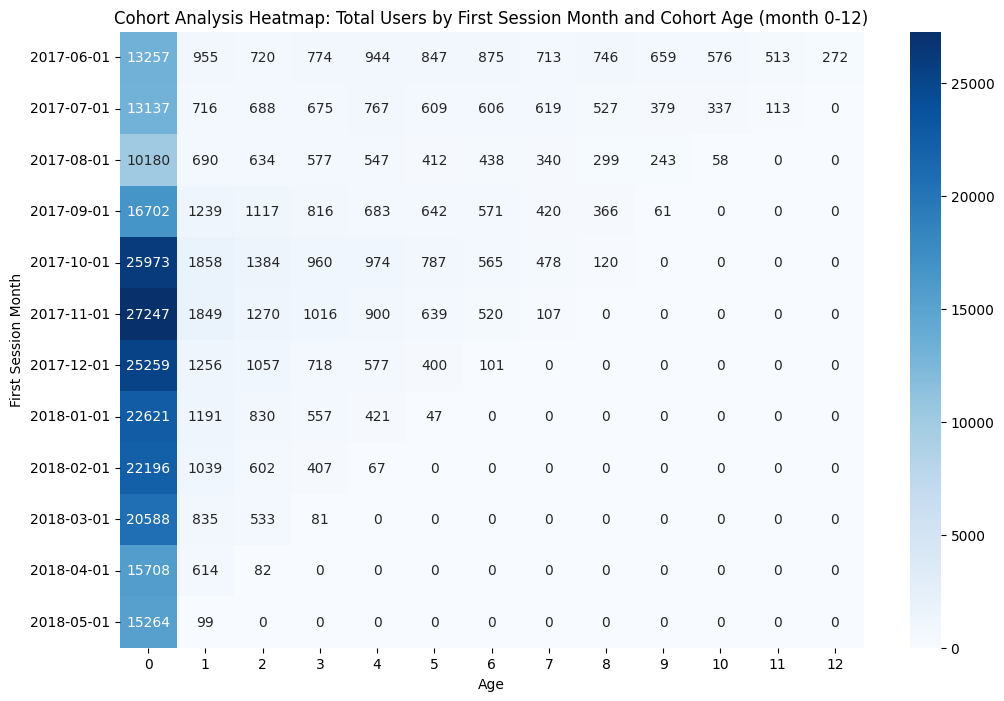

In [ ]:
#formats cohort into a str for a nicer output
cohorts.index=cohorts.index.astype(str)
# Plot a heatmap for cohort analysis
plt.figure(figsize=(12, 8))
sns.heatmap(cohorts, annot=True, fmt='.0f', cmap='Blues')
plt.title('Cohort Analysis Heatmap: Total Users by First Session Month and Cohort Age (month 0-12)')
plt.xlabel('Age')
plt.ylabel('First Session Month')
plt.show()

To calculate retention we find a % of those who are still active from those who registered, that is we divide columns for all ages by column when age=0


In [ ]:
retention=cohorts.iloc[:,0:].div(cohorts[0], axis=0)
retention

age,0,1,2,3,4,5,6,7,8,9,10,11,12
cohort,,,,,,,,,,,,,
2017-06-01,1.0,0.072037,0.054311,0.058384,0.071208,0.063891,0.066003,0.053783,0.056272,0.049710,0.043449,0.038697,0.020517
2017-07-01,1.0,0.054503,0.052371,0.051382,0.058385,0.046358,0.046129,0.047119,0.040116,0.028850,0.025653,0.008602,0.000000
2017-08-01,1.0,0.067780,0.062279,0.056680,0.053733,0.040472,0.043026,0.033399,0.029371,0.023870,0.005697,0.000000,0.000000
2017-09-01,1.0,0.074183,0.066878,0.048856,0.040893,0.038439,0.034188,0.025147,0.021914,0.003652,0.000000,0.000000,0.000000
2017-10-01,1.0,0.071536,0.053286,0.036961,0.037500,0.030301,0.021753,0.018404,0.004620,0.000000,0.000000,0.000000,0.000000
2017-11-01,1.0,0.067861,0.046611,0.037289,0.033031,0.023452,0.019085,0.003927,0.000000,0.000000,0.000000,0.000000,0.000000
2017-12-01,1.0,0.049725,0.041846,0.028426,0.022843,0.015836,0.003999,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
2018-01-01,1.0,0.052650,0.036692,0.024623,0.018611,0.002078,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
2018-02-01,1.0,0.046810,0.027122,0.018337,0.003019,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000


To compare retention rate for different cohorts at different ages heatmap will come in handy.


In [ ]:
#formats cohort into a str for a nicer output
retention.index=retention.index.astype(str)


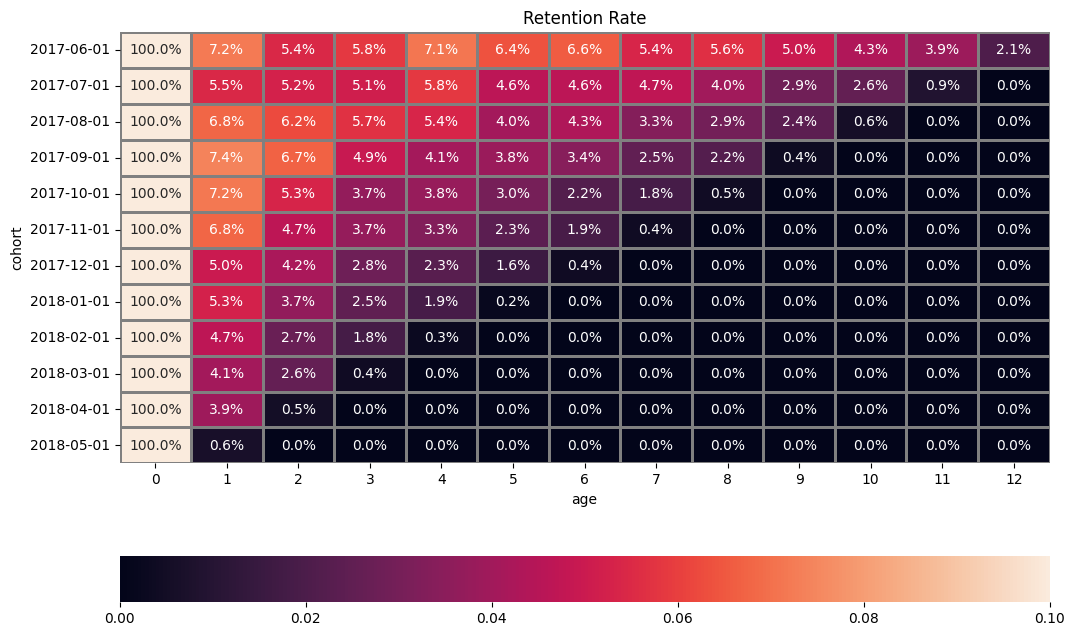

In [ ]:
#plot heatmap
plt.figure(figsize=(12, 8))
sns.heatmap(retention, annot=True, fmt='.1%', linewidths=1, linecolor='grey', vmax=0.1, cbar_kws= {'orientation': 'horizontal'}
            ).set(title = 'Retention Rate')
plt.show()

The heatmap clearly shows the retention rate(RR) dynamics. All cohorts' RR0(retention rate at the age of 0 months) > RR1 > RR2. But futher there are 2 variants.

- The first cohort(starting in June) in a month has 7.2 of its users still active, then only 5.4%. At the age of 3 months retention rate rises to 6.2% and remains relatively high for 3 months, than gradually falls to 0.7% at the 12th month. The second(July) cohort has smaller retention rate in a month - only 5.7%(we already know that in august all users show min activity)> then it was smaller for 2 months and again rose to 5.7 in the age of 5 months( which was November the great!). The first two cohorts had the same pattern: RR0> RR1> RR2 < RR3 < RR4 > RR5 > RR6..., that is after initial decline of retention rate we see a certain rise, then fall again.
- All other cohorts have no rise, their RR is only descending.

Max retention at 1 month age - 7.4% - was at September cohort. February, March, April cohorts have RR less than 5 % from the very beginning. At the end of the period observed(May) max retention - 4 % - was demonstrated by June cohort(its 12th month) and April cohort(age 1 month - no wonder)! June data are incomplete and won't be analized.



## Conclusion

User Metrics were calculated, they show how users interact with the app.

- **overall average DAU** is 908 unique users per day,
- **average WAU** is 5716 unique users per week,
- **average MAU** is 23225 unique users per month.

Their **dynamics over the year** has much in common. For nearly half a year(October - March) DAU, WAU and MAU are above average. with the peak value on Nov.24 (BLACK FRIDAY?), before the winter holidays(Cristmass, New Year). Since Aprile DAU, WAU, MAU are below average, min values are in august(people are on vacation). There's a sudden drop down around Mar 31 for all metrics. We can also see small regular rises and falls during the week as weekly cycle:  people open the app most often on Thursday, then on Monday, while min number of visits is on weekends (Saturday, Sunday).

**Number of sessions per day** on average is 987 - it is greater than DAU, but the distribution over the year, peaks and falls, week cycles are pretty similar(line graphs almost coincide).

**Number of sessions per user** varies from 1 to 1.22 with the mean 1.08. Unlike other metrics,it is normally distributed, but there are also regular weekly ups and downs, max value is again on Nov 24(Black Friday), min on Mar 31 and in August.

**Mean value of session length** is 10 min 43sec and some users hang on the site up to 700 min, but 50% of sessions last less than 5 min, 10% of sessions last less than 15 sec, that can be a signal of some issues with the app.

**Cohort analysis was made** for calculating retention rate(RR) as a % of those users who are still active at a certain period of time. Heatmap for RR for all cohorts at all ages was ploted and RR dynamics was determined. All cohorts' RR0(retention rate at the age of 0 months) > RR1 > RR2. But then there are 2 scenarios:
- after initial fall RR can rise again and after 2-3 months begin to fall again(June and July cohorts)
- no rise, RR is falling every month(all other cohorts).

RR in the first 2 cohorts may rise because in october the general rise in user's activity begins(as we already know about DAU/WAU/MAU and other metrics' dynamics over the year).

At the age of 1 month max retention was 7.8% (September cohort). April, March cohorts activity is the least - RR1 around 4%.
At the end of the period observed(May) max retention - 4 % - was demonstrated by June cohort(its 12th month) and April cohort(age 1 month - no wonder).

# Step 4. Purchase and Conversion Analysis

## Task 11: Calculate the conversion rate from first visit to first purchase

**Conversion rate** is % of users who made an order(were converted to customers), conversion time depicts how long does it take from first visit to the purchase in days. So for each user we find the distance between the date of first visit and the date of first order.

To calculate the conversion rate from a user's first visit to their first purchase - the proportion of users who made a purchase after their first visit:
- identify the first visit date for each user - we'll find the date for the first end_ts (end of the first session) - it can be different from 1st start_ts
- the first purchase date
- checking how many users made a purchase after their first visit = number of rows where purchase date is smaller or equal to 1st end_ts.

In [ ]:
# extract date from end_ts
visits['end_date'] = visits['end_ts'].dt.date

In [ ]:
first_visits = visits.groupby('uid')['end_date'].min().reset_index(name = 'first_visit_end')
first_orders = orders.groupby('uid')['date'].min().reset_index(name= 'first_order_date')
# Merge both dataframes to check users who made a purchase after their first visit
first = pd.merge(first_visits, first_orders, on='uid', how='left')
first

,uid,first_visit_end,first_order_date
0,11863502262781,2018-03-01,NaT
1,49537067089222,2018-02-06,NaT
2,297729379853735,2017-06-07,NaT
3,313578113262317,2017-09-18,2018-01-03
4,325320750514679,2017-09-30,NaT
...,...,...,...
228127,18446403737806311543,2017-11-30,NaT
228128,18446424184725333426,2017-12-06,NaT
228129,18446556406699109058,2018-01-01,NaT
228130,18446621818809592527,2017-12-27,NaT


In [ ]:
# A user made a purchase after the first viisit if the first_order_date is <= than the first_visit_date
first['first_visit_purchase'] = first['first_order_date'] <=first['first_visit_end']
first.sample(5)

,uid,first_visit_end,first_order_date,first_visit_purchase
36220,2929969790531487654,2017-10-17,2017-10-17,True
17459,1416552234310571408,2018-02-21,NaT,False
93133,7522382582425178448,2017-10-07,NaT,False
171828,13901702083176406613,2018-02-24,NaT,False
50553,4088448293208701638,2017-06-08,NaT,False


In [ ]:
#number of users making first visit
first.uid.count()

228132

In [ ]:
#number of users with first_visit_purchase
first.first_visit_purchase.sum()

25173

In [ ]:
#calculate the conversion rate from a user's first visit to their first purchase
first_visit_purchase_cnv=100*first.first_visit_purchase.sum()/first.uid.count().round()
first_visit_purchase_cnv.round(1)

11.0

**So**, 11 % of users made their first purchase after their first visit.

## Task 12: Analyze the time between first visit and first purchase

In [ ]:
#To find converion time first drop NaT from first df
first_f = first.dropna()
first_f

,uid,first_visit_end,first_order_date,first_visit_purchase
3,313578113262317,2017-09-18,2018-01-03,False
22,1575281904278712,2017-06-03,2017-06-03,True
35,2429014661409475,2017-10-11,2017-10-11,True
36,2464366381792757,2018-01-27,2018-01-28,False
38,2551852515556206,2017-11-24,2017-11-24,True
...,...,...,...,...
228105,18445147675727495770,2017-08-20,2017-11-24,False
228106,18445407535914413204,2017-09-22,2017-09-22,True
228111,18445601152732270159,2017-08-07,2018-03-26,False
228124,18446156210226471712,2017-11-07,2018-02-18,False


In [ ]:
#check data types
first_f.info()

<class 'pandas.core.frame.DataFrame'>
Index: 36507 entries, 3 to 228125
Data columns (total 4 columns):
 #   Column                Non-Null Count  Dtype         
---  ------                --------------  -----         
 0   uid                   36507 non-null  uint64        
 1   first_visit_end       36507 non-null  object        
 2   first_order_date      36507 non-null  datetime64[ns]
 3   first_visit_purchase  36507 non-null  bool          
dtypes: bool(1), datetime64[ns](1), object(1), uint64(1)
memory usage: 2.2+ MB


In [ ]:
# Convert columns to datetime
first_f['first_order_date'] = pd.to_datetime(first_f['first_order_date'], errors='coerce')
first_f['first_visit_end'] = pd.to_datetime(first_f['first_visit_end'], errors='coerce')

# Calculate conversion time as the difference between first order date and first visit end date
# Calculate conversion time in days
first_f['conversion'] = (first_f['first_order_date'] - first_f['first_visit_end']).dt.days  # This gives the difference in days
first_f['conversion'].describe()


,conversion
count,36507.000000
mean,16.901608
std,47.096227
min,-1.000000
25%,0.000000
50%,0.000000
75%,2.000000
max,363.000000


Conversion varies from 0 to 363 days with the mean around 17, while the median is 0 and 75% of users make order within 2 days from the first session.

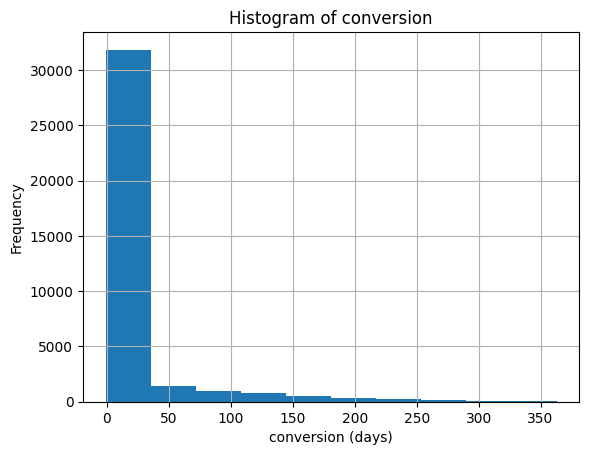

In [ ]:
first_f['conversion'].hist()
plt.xlabel('conversion (days)')
plt.ylabel('Frequency')
plt.title('Histogram of conversion')
plt.show()


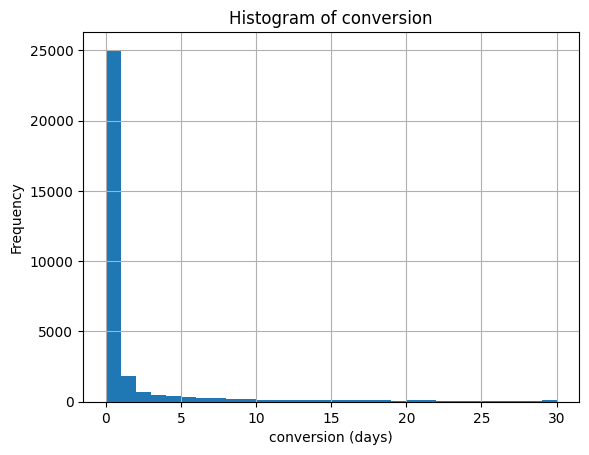

In [ ]:
#There are many upper outliers, so let's zoom the picture.

first_f['conversion'].hist(bins=30, range = (0,30))
plt.xlabel('conversion (days)')
plt.ylabel('Frequency')
plt.title('Histogram of conversion')
plt.show()


So, on average it takes 0 days to convert for a user. But how many users converted at all?

In [ ]:
print(' The overall conversion is {:.1%}'.format(orders['uid'].nunique()/visits['uid'].nunique()))


 The overall conversion is 16.0%


## Task 13: Calculate the number of orders users make over time

In [ ]:
#merging the info on first_order to the orders table
orders=orders.merge(first_orders, how='left',on=['uid'])
orders.head()

,buy_ts,revenue,uid,date,month,first_order_date
0,2017-06-01 00:10:00,17.00,10329302124590727494,2017-06-01,2017-06-01,2017-06-01
1,2017-06-01 00:25:00,0.55,11627257723692907447,2017-06-01,2017-06-01,2017-06-01
2,2017-06-01 00:27:00,0.37,17903680561304213844,2017-06-01,2017-06-01,2017-06-01
3,2017-06-01 00:29:00,0.55,16109239769442553005,2017-06-01,2017-06-01,2017-06-01
4,2017-06-01 07:58:00,0.37,14200605875248379450,2017-06-01,2017-06-01,2017-06-01


Let's define cohort on the first order month.


In [ ]:
orders['first_order_month']=orders['first_order_date'].dt.to_period('M').dt.to_timestamp()
orders.head()

,buy_ts,revenue,uid,date,month,first_order_date,first_order_month
0,2017-06-01 00:10:00,17.00,10329302124590727494,2017-06-01,2017-06-01,2017-06-01,2017-06-01
1,2017-06-01 00:25:00,0.55,11627257723692907447,2017-06-01,2017-06-01,2017-06-01,2017-06-01
2,2017-06-01 00:27:00,0.37,17903680561304213844,2017-06-01,2017-06-01,2017-06-01,2017-06-01
3,2017-06-01 00:29:00,0.55,16109239769442553005,2017-06-01,2017-06-01,2017-06-01,2017-06-01
4,2017-06-01 07:58:00,0.37,14200605875248379450,2017-06-01,2017-06-01,2017-06-01,2017-06-01


In [ ]:
#define cohort size
cohort_sizes = orders.groupby('first_order_month')['uid']. nunique().reset_index()
cohort_sizes.columns=['first_order_month','cohort_size']
cohort_sizes

,first_order_month,cohort_size
0,2017-06-01,2022
1,2017-07-01,1922
2,2017-08-01,1369
3,2017-09-01,2579
4,2017-10-01,4340
5,2017-11-01,4078
6,2017-12-01,4380
7,2018-01-01,3373
8,2018-02-01,3651
9,2018-03-01,3534


In [ ]:
#calculating number of purchases for cohort and month
cohort=orders.groupby(['first_order_month','month'])['revenue'].count().reset_index()
cohort.columns=['first_order_month','month','orders']
cohort

,first_order_month,month,orders
0,2017-06-01,2017-06-01,2353
1,2017-06-01,2017-07-01,177
2,2017-06-01,2017-08-01,171
3,2017-06-01,2017-09-01,224
4,2017-06-01,2017-10-01,291
...,...,...,...
73,2018-03-01,2018-04-01,178
74,2018-03-01,2018-05-01,176
75,2018-04-01,2018-04-01,2487
76,2018-04-01,2018-05-01,195


In [ ]:
#merge cohort with cohort size
cohort=cohort.merge(cohort_sizes,on=['first_order_month'])
cohort.head()

,first_order_month,month,orders,cohort_size
0,2017-06-01,2017-06-01,2353,2022
1,2017-06-01,2017-07-01,177,2022
2,2017-06-01,2017-08-01,171,2022
3,2017-06-01,2017-09-01,224,2022
4,2017-06-01,2017-10-01,291,2022


In [ ]:
cohort.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 78 entries, 0 to 77
Data columns (total 4 columns):
 #   Column             Non-Null Count  Dtype         
---  ------             --------------  -----         
 0   first_order_month  78 non-null     datetime64[ns]
 1   month              78 non-null     datetime64[ns]
 2   orders             78 non-null     int64         
 3   cohort_size        78 non-null     int64         
dtypes: datetime64[ns](2), int64(2)
memory usage: 2.6 KB


In [ ]:
#find cohort's age in months
cohort['age_month'] = (cohort['month'].dt.year - cohort['first_order_month'].dt.year) * 12 + \
                       (cohort['month'].dt.month - cohort['first_order_month'].dt.month)

# Calculate orders per user
cohort['orders_per_user'] = cohort['orders'] / cohort['cohort_size']
cohort.head(15)

,first_order_month,month,orders,cohort_size,age_month,orders_per_user
0,2017-06-01,2017-06-01,2353,2022,0,1.163699
1,2017-06-01,2017-07-01,177,2022,1,0.087537
2,2017-06-01,2017-08-01,171,2022,2,0.084570
3,2017-06-01,2017-09-01,224,2022,3,0.110781
4,2017-06-01,2017-10-01,291,2022,4,0.143917
5,2017-06-01,2017-11-01,218,2022,5,0.107814
6,2017-06-01,2017-12-01,275,2022,6,0.136004
7,2017-06-01,2018-01-01,174,2022,7,0.086053
8,2017-06-01,2018-02-01,212,2022,8,0.104847
9,2017-06-01,2018-03-01,153,2022,9,0.075668


We see that every cohort has max number of orders per user(1.1-1.2) in its first month(age 0), then the value becomes many times smaller.

Let's make pivot table for cohorts' orders per user and compare values for cohorts and months(age).


In [ ]:
cohort_piv=cohort.pivot_table(
    index='first_order_month',
    columns='age_month',
    values='orders_per_user',
    aggfunc='sum'
).cumsum(axis=1)

cohort_piv.round(2).fillna('')


age_month,0,1,2,3,4,5,6,7,8,9,10,11
first_order_month,,,,,,,,,,,,
2017-06-01,1.16,1.25,1.34,1.45,1.59,1.7,1.83,1.92,2.03,2.1,2.15,2.19
2017-07-01,1.14,1.19,1.25,1.31,1.34,1.39,1.42,1.44,1.47,1.49,1.51,
2017-08-01,1.12,1.2,1.27,1.33,1.39,1.44,1.47,1.53,1.56,1.6,,
2017-09-01,1.14,1.22,1.28,1.35,1.37,1.41,1.46,1.48,1.5,,,
2017-10-01,1.14,1.22,1.25,1.28,1.31,1.34,1.35,1.38,,,,
2017-11-01,1.18,1.27,1.32,1.37,1.4,1.42,1.44,,,,,
2017-12-01,1.15,1.21,1.26,1.3,1.32,1.34,,,,,,
2018-01-01,1.12,1.19,1.24,1.25,1.28,,,,,,,
2018-02-01,1.12,1.18,1.2,1.22,,,,,,,,


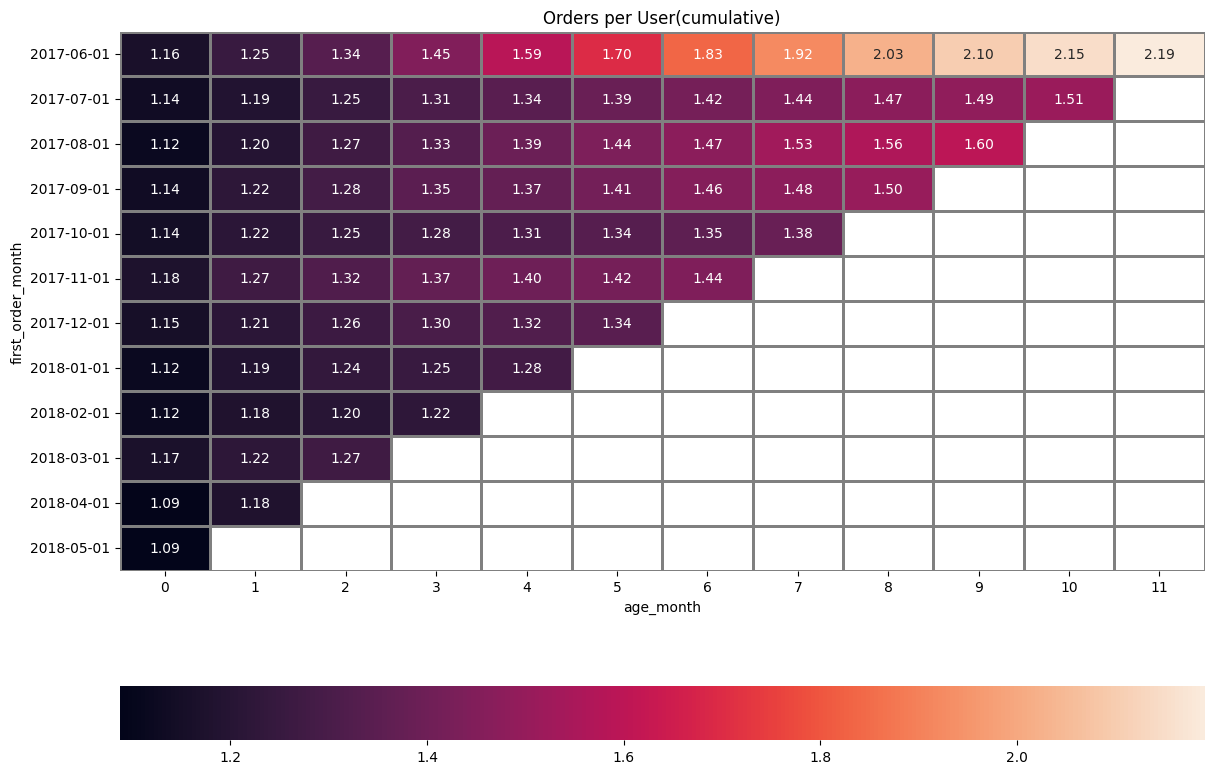

In [ ]:
plt.figure(figsize=(14, 10))
cohort_piv.index=cohort_piv.index.astype(str)
sns.heatmap(cohort_piv, annot=True, fmt='.2f', linewidths=1, linecolor='grey', cbar_kws= {'orientation': 'horizontal'}
            ).set(title ='Orders per User(cumulative)')
plt.show()

At the age of 0 and 1 max orders per user is at November cohort - 1.18, 1.28 (no wonder, November is a the happiest month, December is also very active). After that(since age 2) the June cohort becomes the leader and has max cumulative orders per user, but November cohort still has very good results. April and May cohorts are the weakest - cum.orders/user 1.10, 1.09.

## Task 14: Calculate the average purchase size and analyze by cohort

The overall average purchase size:

In [ ]:
orders.revenue.mean()

5.004741179040169

We can group by uid and find average check per user

In [ ]:
avg_check = orders.groupby('uid').revenue.mean()
avg_check.describe()

,revenue
count,36508.000000
mean,4.094925
std,7.672304
min,0.030000
25%,1.303333
50%,2.500000
75%,4.890000
max,657.466250


Average purchase size varies a lot - 0.3 to 657.5, the median is 2.5. Plot a histogram

<Axes: >

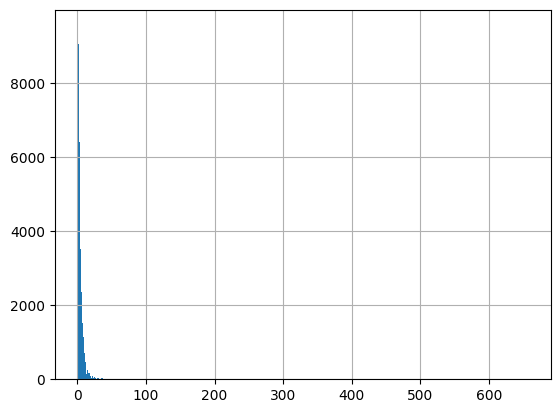

In [ ]:
avg_check.hist(bins = 500)

In [ ]:
# calculating total check for each user and plotting it
tot_check=orders.groupby(['uid'])['revenue'].sum().reset_index()
tot_check.describe()

,uid,revenue
count,3.650800e+04,36508.000000
mean,9.214359e+18,6.904070
std,5.324475e+18,88.146532
min,3.135781e+14,0.030000
25%,4.615634e+18,1.470000
50%,9.247517e+18,3.050000
75%,1.383727e+19,5.800000
max,1.844617e+19,11810.180000


User's total check varies a lot - from 0.03 to 11810, mean revenue is 6.9, but the median is only 3, so the distribution is not normal, but right skewed.

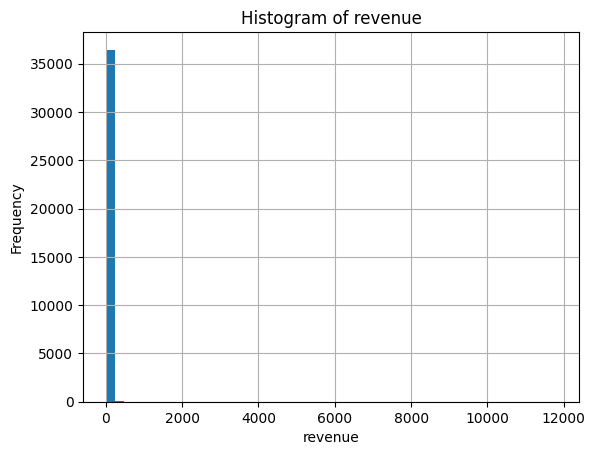

In [ ]:
# calculating total check for each order and plotting it
tot_check['revenue'].hist(bins=50)
plt.xlabel('revenue')
plt.ylabel('Frequency')
plt.title('Histogram of revenue')
plt.show()

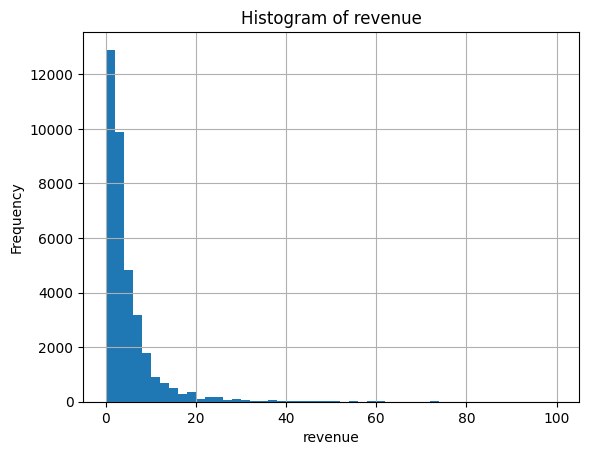

In [ ]:
#zooming
tot_check['revenue'].hist(bins=50, range = (0,100))
plt.xlabel('revenue')
plt.ylabel('Frequency')
plt.title('Histogram of revenue')
plt.show()

In [ ]:
#Cohort analysis on averge check:

avg_cohort=orders.groupby(['first_order_month','month'])['revenue'].mean().reset_index()
avg_cohort['age_month'] = (cohort['month'].dt.year - cohort['first_order_month'].dt.year) * 12 + \
                       (cohort['month'].dt.month - cohort['first_order_month'].dt.month)
avg_cohort.head()

,first_order_month,month,revenue,age_month
0,2017-06-01,2017-06-01,4.061832,0
1,2017-06-01,2017-07-01,5.547006,1
2,2017-06-01,2017-08-01,5.177427,2
3,2017-06-01,2017-09-01,8.621875,3
4,2017-06-01,2017-10-01,7.108522,4


In [ ]:
#Now group data in a pivot table with mean revenue value for age(months):

avg_cohort_piv=avg_cohort.pivot_table(
    index='first_order_month',
    columns='age_month',
    values='revenue',
    aggfunc='mean'
)
avg_cohort_piv.round(2).fillna('')

age_month,0,1,2,3,4,5,6,7,8,9,10,11
first_order_month,,,,,,,,,,,,
2017-06-01,4.06,5.55,5.18,8.62,7.11,6.83,6.99,6.76,5.28,8.01,12.04,6.04
2017-07-01,5.29,6.45,9.99,6.64,4.72,3.66,3.79,5.45,5.35,11.79,5.65,
2017-08-01,4.72,5.99,6.28,6.62,7.96,6.27,5.89,7.11,8.7,5.6,,
2017-09-01,4.97,13.23,8.38,62.57,15.43,15.32,16.92,11.21,7.79,,,
2017-10-01,4.37,7.41,5.13,5.59,5.1,5.07,4.28,4.01,,,,
2017-11-01,4.38,4.17,4.47,6.28,4.47,3.73,4.6,,,,,
2017-12-01,4.11,4.23,20.07,26.08,15.95,14.11,,,,,,
2018-01-01,3.69,4.44,6.45,7.52,2.71,,,,,,,
2018-02-01,3.71,4.58,3.45,3.87,,,,,,,,


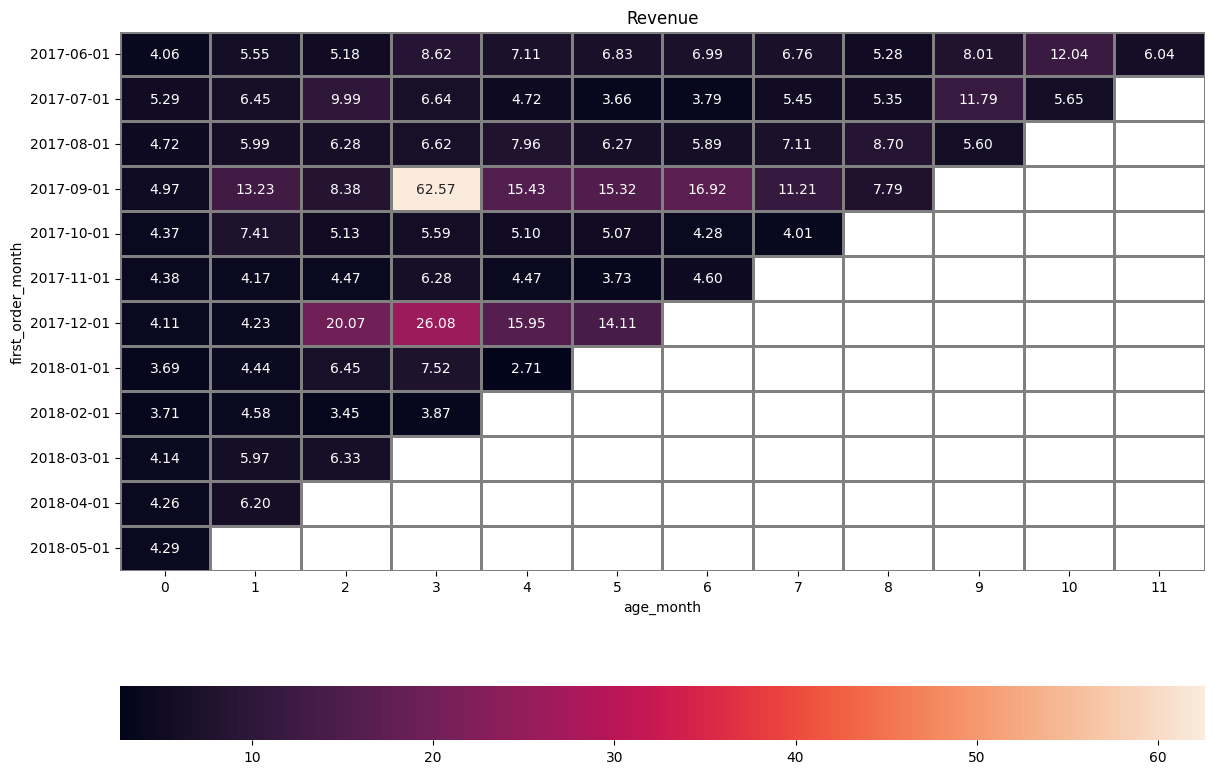

In [ ]:
plt.figure(figsize= (14,10))
avg_cohort_piv.index=avg_cohort_piv.index.astype(str)
sns.heatmap(avg_cohort_piv, annot=True, fmt='.2f', linewidths=1, linecolor='grey', cbar_kws= {'orientation': 'horizontal'}
            ).set(title ='Revenue')
plt.show()


At the age of 0 July cohort had max revenue(5.29). At the age of 1 month September cohort pulled ahead with revenue 13.23, and it had absolute max revenue(62.57) at the age of 3 which was in December and was the leader till January. We can see good results in December cohort, which became the first at its age 2(20.07 in February) and then in March, April, May. Min revenue brought January cohort.

## Task 15: Calculate the LTV (Lifetime Value) of customers

Ltv is the total amount of money the average customer brings to the company by making purchases. It's calculated as gross profit from a customer per period. For this project we can keep margin rate=1, so gp=revenue


In [ ]:
#get the revenue per cohort in each month
ltv_cohort=orders.groupby(['first_order_month','month'])['revenue'].sum().reset_index()
ltv_cohort.head()


,first_order_month,month,revenue
0,2017-06-01,2017-06-01,9557.49
1,2017-06-01,2017-07-01,981.82
2,2017-06-01,2017-08-01,885.34
3,2017-06-01,2017-09-01,1931.30
4,2017-06-01,2017-10-01,2068.58


In [ ]:
#merge with the cohort size
ltv_cohort=ltv_cohort.merge(cohort_sizes,on=['first_order_month'])
ltv_cohort.head()


,first_order_month,month,revenue,cohort_size
0,2017-06-01,2017-06-01,9557.49,2022
1,2017-06-01,2017-07-01,981.82,2022
2,2017-06-01,2017-08-01,885.34,2022
3,2017-06-01,2017-09-01,1931.30,2022
4,2017-06-01,2017-10-01,2068.58,2022


In [ ]:
# calculate the age in months
ltv_cohort['age'] = (ltv_cohort['month'].dt.year - ltv_cohort['first_order_month'].dt.year) * 12 + \
                    (ltv_cohort['month'].dt.month - ltv_cohort['first_order_month'].dt.month)

# calculate LTV
ltv_cohort['ltv'] = ltv_cohort['revenue'] / ltv_cohort['cohort_size']
ltv_cohort.head()

,first_order_month,month,revenue,cohort_size,age,ltv
0,2017-06-01,2017-06-01,9557.49,2022,0,4.726751
1,2017-06-01,2017-07-01,981.82,2022,1,0.485569
2,2017-06-01,2017-08-01,885.34,2022,2,0.437854
3,2017-06-01,2017-09-01,1931.30,2022,3,0.955143
4,2017-06-01,2017-10-01,2068.58,2022,4,1.023037


In [ ]:
# Calculate LTV with cumsum in pivot table
ltv_cohort_piv=ltv_cohort.pivot_table(
    index='first_order_month',
    columns='age',
    values='ltv',
    aggfunc='sum'
).cumsum(axis=1)
ltv_cohort_piv

age,0,1,2,3,4,5,6,7,8,9,10,11
first_order_month,,,,,,,,,,,,
2017-06-01,4.726751,5.212319,5.650173,6.605317,7.628353,8.364219,9.314416,9.896296,10.449782,11.055870,11.627413,11.884397
2017-07-01,6.013345,6.348730,6.972586,7.331748,7.508632,7.664761,7.785031,7.926925,8.088241,8.235463,8.391217,NaN
2017-08-01,5.280373,5.752710,6.211527,6.603090,7.097502,7.381249,7.592067,7.997370,8.289795,8.477911,NaN,NaN
2017-09-01,5.648907,6.767359,7.287297,11.266173,11.667041,12.314610,13.016762,13.260101,13.444250,NaN,NaN,NaN
2017-10-01,5.003733,5.539495,5.730889,5.888035,6.039594,6.159956,6.244772,6.360242,NaN,NaN,NaN,NaN
2017-11-01,5.159358,5.558166,5.757869,6.083060,6.230964,6.284882,6.399895,NaN,NaN,NaN,NaN,NaN
2017-12-01,4.742434,5.002986,5.928717,6.994721,7.307865,7.646144,NaN,NaN,NaN,NaN,NaN,NaN
2018-01-01,4.135636,4.430394,4.734675,4.877453,4.940151,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2018-02-01,4.156987,4.435262,4.513777,4.587921,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


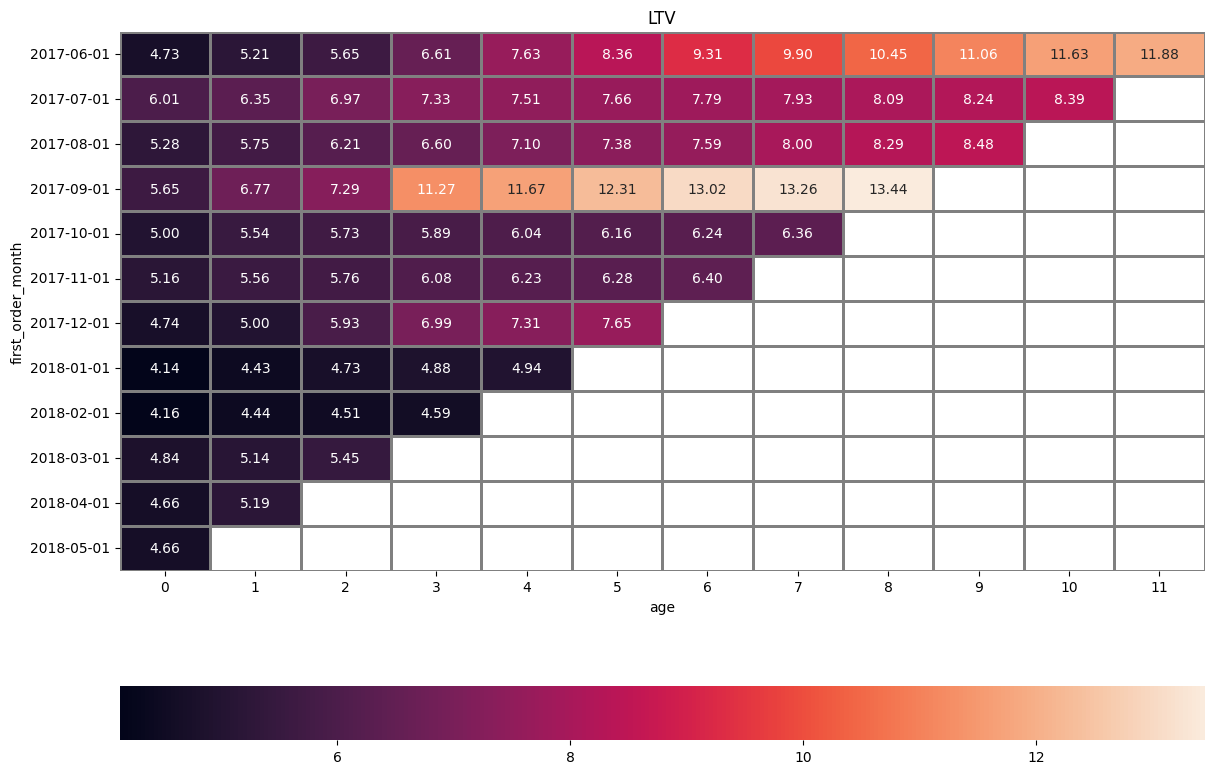

In [ ]:
#visualize it with heatmap.
plt.figure(figsize= (14,10))
ltv_cohort_piv.index=ltv_cohort_piv.index.astype(str)
sns.heatmap(ltv_cohort_piv, annot=True, fmt='.2f', linewidths=1, linecolor='grey', cbar_kws= {'orientation': 'horizontal'}
            ).set(title ='LTV')
plt.show()


Cumulative LTV naturally grows in all rows. Again September cohort is the leader - it has max LTV since age 1(Oktober) throgh most profitable Nov,Dec till May, reaching the value of 13.44. If we compare diagonal values, June cohort starts out - it has max of all cohorts LTV in Oct(age 4 - 7.62) and Nov, then it is the second after September cohort. The least profitable is February cohort with min LTV(4.59).


## **Conclusion**

Sales metrics were calculated.

The overall conversion is 16.0%, and 50% of users make order and become customers on the same day as they are registered so the median of conversion time is 0. 75% of users make order within 2 days from the first session, but the mean conversion time is much higher (around 17), some users wait up to 363 days before ordering.

Number of orders per user was calculated for month cohorts. Every cohort has max number of orders per user in its first month(age 0), then the value becomes many times smaller, but cumulative sum is gradually rising. At the age of 0 and 1 max cum orders per user is at November cohort - 1.18, 1.28 (no wonder, November is a the happiest month due to Black Friday, December is also very active). After that(since age 2) the June cohort becomes the leader and has max cumulative orders per user. April and May cohorts are the weakest - cum.orders/user 1.10, 1.09.

User's total check for revenue is 6.9(the mean), but the median is only 3, so the distribution is right skewed with outliers up to 11810. 0 revenues(0,1%) were excluded from cohort analysis. At the age of 0 July cohort had max revenue(5.29). At the age of 1 month September cohort pulled ahead with revenue 13.23, and it had absolute max revenue(62.57) at the age of 3 which was in December and was the leader till January. We can see good results in December cohort, which became the first at its age 2(20.07 in February) and then in March, April, May. Min revenue brought January cohort.

Cumulative LTV naturally grows in all rows. Again September cohort brought to the company max money - it has max LTV since age 1(Oktober) throgh most profitable Nov,Dec till May, reaching the value of 13.44. The second is June cohort (cum LTV 11.88). The weakest is February cohort with min LTV(4.59).



# Step 5. Marketing Analysis

## Task 16: Calculate total marketing expenses and expenses by source

Cost: overall and per source

Here we deal with costs dataset.

In [ ]:
#sorting cost for futher visualization
costs=costs.sort_values(by=['dt','source_id'])
costs.head()

,source_id,dt,costs,month
0,1,2017-06-01,75.20,2017-06-01
363,2,2017-06-01,132.56,2017-06-01
726,3,2017-06-01,349.38,2017-06-01
1089,4,2017-06-01,76.74,2017-06-01
1452,5,2017-06-01,73.24,2017-06-01


In [ ]:
# find total marketing
print('Total marketing cost is {}'.format(costs['costs'].sum()))


Total marketing cost is 329131.62


So, total amount spent on marketing by the company is $329131.62. Let's find its distribution by source.


In [ ]:
marketing_source=costs.groupby(['source_id'])['costs'].sum()
marketing_source

,costs
source_id,
1,20833.27
2,42806.04
3,141321.63
4,61073.60
5,51757.10
9,5517.49
10,5822.49


In [ ]:
# Calculate the percentage of each source's cost over the total
percentage = (marketing_source / marketing_source.sum() * 100).round(1)
result = pd.DataFrame({'total_costs': marketing_source, 'percentage': percentage})
result = result.sort_values('total_costs', ascending=False).reset_index()
result

,source_id,total_costs,percentage
0,3,141321.63,42.9
1,4,61073.60,18.6
2,5,51757.10,15.7
3,2,42806.04,13.0
4,1,20833.27,6.3
5,10,5822.49,1.8
6,9,5517.49,1.7


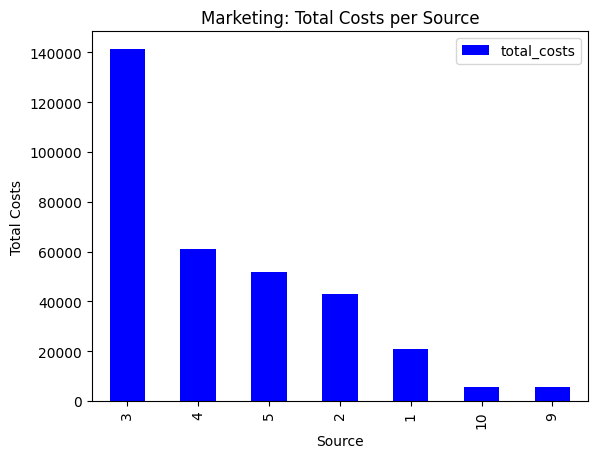

In [ ]:
# Plot the barplot for total costs per source
result.plot(kind='bar', x='source_id', y='total_costs', color='blue')
plt.xlabel('Source')
plt.ylabel('Total Costs')
plt.title('Marketing: Total Costs per Source')
plt.show()

So, most of the money was spent on source 3(43% of costs, 141321.63 costs), the smallest amount was spent on sources 9,10 (less than 2%).

## Task 17: Calculate Customer Acquisition Cost (CAC) per month

Let's see how costs change over time - each day, month, over the week.


In [ ]:
import plotly.express as px
fig = px.line(costs, x="dt", y="costs", color='source_id')
fig.show()

Lines for all sources are shown on the graph. Source 3 has max values and max fluctuation range, soeces 9,10 have min values.The highest peak for all source is on Nov 24 - as expected, min costs were spent on Mar 31(end of quarter?) and in august(people on holidays). There're also some minor peaks for source1: Okt 6, Okt 27, Nov 3, Dec 11, Dec 28, Jan3, Mar 7, May 31, June 8. Close to them but not always matching are peaks for source 4: Dec 5,14, Jan 16,22, Feb 13, Mar 10,12, June 9, Jul 14. For some reason there's no special activity of source 4 around Nov 24 - on the contrary, its costs are pretty smalll on Nov 24. Source 5 has max costs on Nov 24 oand just one more peak on May 31.

Let's unite all the sources and see the whole marketing costs distribution over the year.


In [ ]:
total_date=costs.groupby(['dt'])['costs'].sum().reset_index()
total_date

,dt,costs
0,2017-06-01,735.26
1,2017-06-02,721.19
2,2017-06-03,450.85
3,2017-06-04,761.16
4,2017-06-05,821.44
...,...,...
359,2018-05-27,532.87
360,2018-05-28,619.44
361,2018-05-29,784.79
362,2018-05-30,1183.00


In [ ]:
fig = px.line(total_date,x="dt", y="costs",title='Costs per day')

fig.add_hline(y=total_date['costs'].mean(),line_dash="dash", line_color="purple", annotation_text="average costs",
             annotation_position="top left")
fig.show()

This graph is very similar to DAU/WAU/MAU/number of sessions per day lineplots with the same peak on Nov 24 and min costs spent in August and sudden fall on Mar 31.

Let's compare with revenue distribution over the year.


In [ ]:
revenue_date=orders.groupby(['date'])['revenue'].sum().reset_index()
fig = px.line(revenue_date,x="date", y="revenue",title='Revenue per day')

fig.add_hline(y=revenue_date['revenue'].mean(),line_dash="dash", line_color="purple", annotation_text="average costs",
             annotation_position="top left")
fig.show()

There's less correlation than with DAU/...metrics. The highest peak is not on Nov 24, but on Dec 10 (related with max activity of source 5 supported by other sources? people buy more tickets before winter holidays?) and May 31. Revenue in January falls below average(users have already spent all the money) till Jan 26, Feb 1 and stay above average till the end of March. Min revenue on Mar 31 and in august correlates with min marketing costs.

Let's find monthly marketing costs and compare them with revenue.


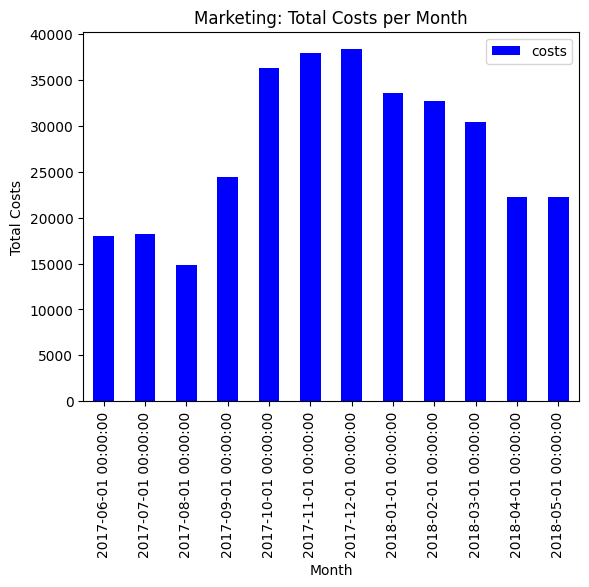

In [ ]:
marketing_month=costs.groupby(['month'])['costs'].sum().reset_index()
marketing_month.plot(kind='bar', x='month', y='costs', color='blue')
plt.xlabel('Month')
plt.ylabel('Total Costs')
plt.title('Marketing: Total Costs per Month')
plt.show()

So, the largest costs are spent on marketing in December, November, October, the smallest costs are is August.

In Oct, Nov and Dec marketing costs gradually grow, that correlates with growing revenues and max revenue in December. In January costs remain relatively high, though revenue falls below average. Costs decrease from jan to March, while DAU/MAU doesn't change much and revenue per day grows towards March. Costs in June and July are the equal, but revenue and users activity rises significantly around July 17. Mayby marketing costs should support natural user's activity in February, March and July.

There're also weekly fluctuations in costs, as in user activity metrics.


In [ ]:
costs['dow'] = costs['dt'].dt.dayofweek
total_dow=costs.groupby(['dow'])['costs'].sum()
total_dow

,costs
dow,
0,48142.06
1,47375.75
2,45967.47
3,55486.33
4,52509.77
5,40236.95
6,39413.29


There's definetly a difference in costs depending on day of the week. Let's plot barplot(1 stays for Monday).


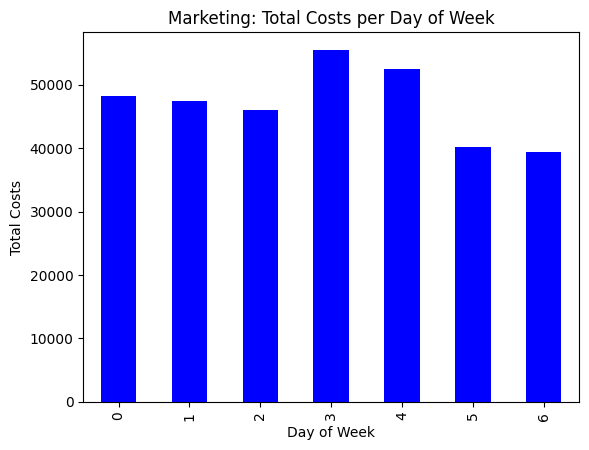

In [ ]:
total_dow.plot(kind='bar', x='dow', y='costs', color='blue')
plt.xlabel('Day of Week')
plt.ylabel('Total Costs')
plt.title('Marketing: Total Costs per Day of Week')
plt.show()

So, the largest amount is spent on marketing on Thursday and Friday , min costs are on Saturday and Sunday. We already know, that users open the app most often on Thursday, then on Monday, while min number of visits is on Saturday and Friday. Maybe the main target days should be Thursday and Monday( not Friday) to attract more customers.

## Task 18: Calculate Customer Acquisition Cost (CAC) per source

**CAC**

In [ ]:
#find number of unique customers making their first order per month
customers_month=orders.groupby(['first_order_month'])['uid'].nunique().reset_index()
customers_month.columns=['month','customers']
customers_month.head()

,month,customers
0,2017-06-01,2022
1,2017-07-01,1922
2,2017-08-01,1369
3,2017-09-01,2579
4,2017-10-01,4340


In [ ]:
#merge with marketing costs per month df
CAC_month=marketing_month.merge(customers_month,how='left',on=['month'])
CAC_month.head()

,month,costs,customers
0,2017-06-01,18015.00,2022
1,2017-07-01,18240.59,1922
2,2017-08-01,14790.54,1369
3,2017-09-01,24368.91,2579
4,2017-10-01,36322.88,4340


In [ ]:
#find costs per new customer
CAC_month['CAC']=CAC_month['costs']/CAC_month['customers']
CAC_month.head()

,month,costs,customers,CAC
0,2017-06-01,18015.00,2022,8.909496
1,2017-07-01,18240.59,1922,9.490421
2,2017-08-01,14790.54,1369,10.803901
3,2017-09-01,24368.91,2579,9.448976
4,2017-10-01,36322.88,4340,8.369327


In [ ]:
fig = px.line(CAC_month, x="month", y="CAC", title='CAC')
fig.show()

Max CAC is in August (10,8), when user's activity is the least,then it goes down till October (8.4), when users become more active. In November attracting a customer costs more than in December (users are active without special push) and March, but less than in January and April (users don't want to buy). Min CAC is in May (7,4)


**CAC per source**

Not all users have one source - there can be multiple sources, let's define the first that they came from as the main source.


In [ ]:
first_source=visits.sort_values('date').groupby('uid').first()['source_id'].reset_index()
first_source.columns=['uid','first_source']
first_source.head()

,uid,first_source
0,11863502262781,3
1,49537067089222,2
2,297729379853735,3
3,313578113262317,2
4,325320750514679,5


Merge this data back to orders becaue CAC calculations are based on buyers


In [ ]:
orders=orders.merge(first_source,on=['uid'],how='left')
orders.head()

,buy_ts,revenue,uid,date,month,first_order_date,first_order_month,first_source
0,2017-06-01 00:10:00,17.00,10329302124590727494,2017-06-01,2017-06-01,2017-06-01,2017-06-01,1.0
1,2017-06-01 00:25:00,0.55,11627257723692907447,2017-06-01,2017-06-01,2017-06-01,2017-06-01,2.0
2,2017-06-01 00:27:00,0.37,17903680561304213844,2017-06-01,2017-06-01,2017-06-01,2017-06-01,2.0
3,2017-06-01 00:29:00,0.55,16109239769442553005,2017-06-01,2017-06-01,2017-06-01,2017-06-01,2.0
4,2017-06-01 07:58:00,0.37,14200605875248379450,2017-06-01,2017-06-01,2017-06-01,2017-06-01,3.0


Let's see how CAC was changing for each source across time


In [ ]:
#sum costs per month for each source_id
marketing_month_source=costs.groupby(['month','source_id'])['costs'].sum().reset_index()
marketing_month_source.head()

,month,source_id,costs
0,2017-06-01,1,1125.61
1,2017-06-01,2,2427.38
2,2017-06-01,3,7731.65
3,2017-06-01,4,3514.80
4,2017-06-01,5,2616.12


In [ ]:
#find number of new customers per month per source
customer_month_source=orders.groupby(['first_order_month','first_source'])['uid'].nunique().reset_index()
customer_month_source.columns=['month','source_id','customers']
customer_month_source.head()

,month,source_id,customers
0,2017-06-01,1.0,215
1,2017-06-01,2.0,236
2,2017-06-01,3.0,626
3,2017-06-01,4.0,405
4,2017-06-01,5.0,383


In [ ]:
#merging tables with data for cac
CAC_month_source=marketing_month_source.merge(customer_month_source,how='left',on=['month','source_id'])
CAC_month_source.head()

,month,source_id,costs,customers
0,2017-06-01,1,1125.61,215
1,2017-06-01,2,2427.38,236
2,2017-06-01,3,7731.65,626
3,2017-06-01,4,3514.80,405
4,2017-06-01,5,2616.12,383


In [ ]:
#actual cac calculations
CAC_month_source['CAC']=CAC_month_source['costs']/CAC_month_source['customers']
CAC_month_source.head()

,month,source_id,costs,customers,CAC
0,2017-06-01,1,1125.61,215,5.235395
1,2017-06-01,2,2427.38,236,10.285508
2,2017-06-01,3,7731.65,626,12.350879
3,2017-06-01,4,3514.80,405,8.678519
4,2017-06-01,5,2616.12,383,6.830601


In [ ]:
#plotting cac dynamics

fig = px.line(CAC_month_source, x="month", y='CAC',color='source_id',title='CAC')
fig.show()

All seven sources are shown, their lines differ much. Sources 3,2,4 have max CAC in August, source 5 - in November, source 1 - in January, source 10 - in December, source 5 - in April. All sources lines fall in May.


Lines for souces 3,2 are much higher than others. Let's calculate overall average CAC per source and compare number of customers and costs.


In [ ]:
source_CAC=CAC_month_source.groupby(['source_id'])[['CAC','customers', 'costs']].agg({'customers': 'sum', 'costs': 'sum', 'CAC': 'mean'}).sort_values(by='CAC', ascending=False)
source_CAC

,customers,costs,CAC
source_id,,,
3,10104,141321.63,14.284608
2,3565,42806.04,12.295973
5,7109,51757.10,7.258998
4,10018,61073.60,6.610988
1,3351,20833.27,6.251307
9,1057,5517.49,5.597069
10,1303,5822.49,4.975071


So, sources 3 and 2 spend much more on attracting a customer than other sources and they bring many customers. But these sources are not so effective as sources 5, 4 ,1: source 4 brings almost as many customers as source 3, but each customers price is 2 times lower, source 1 brings the same number of customers as source 2 at 2 times lower cost. Maybe there's a possibility to reduce costs on less effective sources in favor of most effective sources.


## Return on Investment (ROI)

## Task 19: Calculate ROI per cohort

In genereal, ROI=LTV/CAC

We already have calculations on CAC per month and we have info on ltv in ltv_cohort. So let's merge them.


In [ ]:
CAC_month_ROI=CAC_month[['month','CAC']]
CAC_month_ROI.columns=['first_order_month','CAC']
ROI=ltv_cohort.merge(CAC_month_ROI,on=['first_order_month'],how='left')
ROI.head()

,first_order_month,month,revenue,cohort_size,age,ltv,CAC
0,2017-06-01,2017-06-01,9557.49,2022,0,4.726751,8.909496
1,2017-06-01,2017-07-01,981.82,2022,1,0.485569,8.909496
2,2017-06-01,2017-08-01,885.34,2022,2,0.437854,8.909496
3,2017-06-01,2017-09-01,1931.30,2022,3,0.955143,8.909496
4,2017-06-01,2017-10-01,2068.58,2022,4,1.023037,8.909496


In [ ]:
ROI['ROI']=ROI['ltv']/ROI['CAC']
roi_piv = ROI.pivot_table(index='first_order_month', columns='age', values='ROI', aggfunc='mean').cumsum(axis=1).round(2)


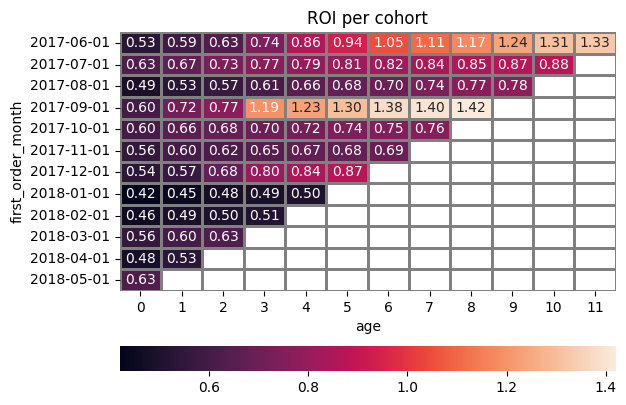

In [ ]:
roi_piv.index=roi_piv.index.astype(str)
sns.heatmap(roi_piv, annot=True, fmt='.2f', linewidths=1, linecolor='grey', cbar_kws= {'orientation': 'horizontal'}
            ).set(title ='ROI per cohort')
plt.show()


Again we see the best results for September cohort reaching ROI 1.42 and June cohort ROI 1.33. Only these cohorts' ROI is above 1, so campaign's gross profit exceeds expenses. Other cohorts have ROI smaller than 1, so for them ad campaing doesn't pay off.


## Task 20: Calculate ROI per marketing source

In [ ]:
#ROI per source
ltv_source=orders.groupby(['first_source'])[['uid','revenue']].agg({'uid':'nunique','revenue':'sum'}).reset_index()
ltv_source.columns=['source_id','customers','revenue']
ltv_source['ltv']=ltv_source['revenue']/ltv_source['customers']
ltv_source

,source_id,customers,revenue,ltv
0,1.0,3352,34371.54,10.254039
1,2.0,3561,45894.50,12.888093
2,3.0,10119,52001.09,5.138955
3,4.0,10015,55267.61,5.518483
4,5.0,7101,54366.53,7.656179
5,9.0,1056,5553.95,5.259422
6,10.0,1303,4597.34,3.528273


In [ ]:
marketing_source=marketing_source.reset_index()
marketing_source

,source_id,costs
0,1,20833.27
1,2,42806.04
2,3,141321.63
3,4,61073.60
4,5,51757.10
5,9,5517.49
6,10,5822.49


In [ ]:
roi_source=marketing_source.merge(ltv_source,on=['source_id'])
roi_source['cac']=(roi_source['costs']/roi_source['customers']). round(2)
roi_source['romi']=(roi_source['ltv']/roi_source['cac']).round(2)
roi_source

,source_id,costs,customers,revenue,ltv,cac,romi
0,1,20833.27,3352,34371.54,10.254039,6.22,1.65
1,2,42806.04,3561,45894.50,12.888093,12.02,1.07
2,3,141321.63,10119,52001.09,5.138955,13.97,0.37
3,4,61073.60,10015,55267.61,5.518483,6.10,0.90
4,5,51757.10,7101,54366.53,7.656179,7.29,1.05
5,9,5517.49,1056,5553.95,5.259422,5.22,1.01
6,10,5822.49,1303,4597.34,3.528273,4.47,0.79


In [ ]:
fig = px.bar(roi_source, x='source_id', y='romi')
fig.update_xaxes(type='category')
fig.show()

So, source 1 has max ROMI(1.8), sources 2 and 5 also have ROMI > 1 ,so they are profitable. Source 9 has ROMY equal to 1. Source 3 has min ROMI 0.37, sources 10 - 0.78, source 4 - 0.9. Probably sources 3 and 10 should be cut out, while the flow from sources 1,2,5 should be increased.

# Return on Marketing Investment (ROMI)

## Task 21: Calculate ROMI (Return on Marketing Investment) for each marketing source - above

## Conclusions

Marketing metrics were calculated and analized.

- Total marketing expenses are $329131.62. Max share per source - source 3(43%), min costs - sources 9,10(less than 2%).
- Over time: the highest peak for almost all sources is on Nov 24 - as expected, min costs were spent on Mar 31(end of quarter?) and in august(people on holidays). There're also some minor peaks for sources 1, 4, 5 which often(not always) match. For some reason there's no special activity from source 4 around Nov 24 - on the contrary, its costs are pretty small on Nov 24.

The distribution of total costs over time is compared with:

 -- DAU/WAU/MAU/number of sessions per day lineplots - very similar to total costs, with the same peak on Nov 24 and min costs spent in August and sudden fall on Mar 31

 -- revenue distribution over time - less correlation found. The highest revenue peak is not on Nov 24, but on Dec 10 (related with max activity of source 5 supported by other sources? people buy more expensive goods befor the main holidays) and May 31. Revenue in January falls below average(users have spent all the money on expensive presents) till Jan 26, Feb 1 and stay above average till the end of March. Min revenue on Mar 31 and in august correlates with min marketing costs.


- Marketing expences per month: max marketing expences are in December, November, and October, the smallest is is August. In Oct, Nov and Dec marketing costs gradually grow, that correlates with growing revenues and max revenue in December. In January costs remain relatively high, though revenue falls below average. Costs decrease from jan to March, while DAU/MAU doesn't change much and revenue per day grows towards March. Costs in june and July are the same, but revenue and users activity rises significantly around July 17. Mayby marketing costs should support more natural user's activity in February, March and July?

- Marketing expences by day of the week: regular weakly cycles are seen on the graph for daily costs like on DAU and revenue graphs. Max marketing costs are spent on then Thursday and Friday, min costs are on Saturday. As we have already seen users open the app most often on Thursday  and Monday, while min number of visits is on weekends. Maybe the main target days should be Thursday and Monday(not Friday) to attract more customers.

- CAC over time: Max CAC is in August(10,8), when user's activity is the least, then it goes down till October(8.4), when users become more active. In November attracting a customer costs more than in December(users are active without special push) and March, but less than in January and April(users don't want to buy). Min CAC is in May(7,4).

- CAC per source: Sources 3 and 2 spend much more on attracting a customer than other sources and they bring many customers. But these sources are not so effective as sources 5,4,1: Source 4 brings almost as many customers as source 3, but each customers price is 2 times lower, source 1 brings the same number of customers as source 2 at 2 times lower cost. Maybe there's a possibility to reduce costs on less effective sources in favor of most effective sources.

- ROI in cohort analysis: The best results for September cohort reaching ROI 1.42 and June cohort ROI 1.33. Only these cohorts' ROI is above 1, so campaign's gross profit exceeds expenses. Other cohorts have ROI smaller than 1, so for them ad campaing doesn't pay off.

- ROI per source: source 1 has max ROMI(1.8), sources 2 and 5 also have ROMI > 1 ,so they are profitable. Source 9 has ROMY equal to 1. Source 3 has min ROMI 0.37, sources 10 - 0.78, source 4 - 0.9. Probably sources 3 and 10 should be cut out, while the flow from sources 1,2,5 should be increased.



# Conclusions

Our conclusions about user's activity, sales and marketing metrics help to find problems with the app and recommend some changes in marketing organization.

**User's activity**:
DAU, WAU, MAU  are above average since October till April and has peaks on Nov 24, May 31.  User activity is minimal in August when people are on vacation. Maximum user activity occurs on Thursday and Monday (max DAU, number of sessions per user, session length),

**Cohorts**:
Max activity was shown by June and September user cohorts - max retention, max cumulatibe orders per user, revenue, LTV , ROI, while other cohorts were only effective in some periods by some metrics( eg.December cohort had max revenue in February, March, April). These profitable cohorts are supported not only by natural factors such as rises in users activity over the year, but also by special marketing efforts. Marketing department should use this positive experience to support other cohorts.

**Sources**:
Max share of marketing expences(43% of all costs) is related with source 3, min costs (less than 2%) with sources 9,10. Sources 4 ,5 , 1 get only 18.6%, 15.7% , 6,3% respectively (summed less than source 3), but they are much more effective!

Comparing **CAC per source** shows that sources 3 and 2 have max CAC(14.2) 12.3), so source 4 brings almost as many customers as source 3 with 2 times lower CAC(6.6), source 5 brings 2 times more customers than source 2 with 2 times lower CAC? source 1 brings the same number of customers as source 2 at 2 times lower cost.

Analizing **return on marketing investments** we find that only sources 1,2,5 have ROMI >1 ( max 1.8 - source 1) and make profit, source 9 has ROMY equal to 1, other sources don't pay off. Source 3 has min ROMI 0.37, sources 10 - 0.78. Probably sources 3 and 10 should be cut out, while the flow from sources 1,2,5 should be increased to reduce costs on less effective sources in favor of most effective sources.

**Over time**:
In general, marketing expenses are distributed over the year in correlation with user's activity.
- by day: Most sources spend max costs on Nov 24 (Black Friday), and users also demonstrate max activity on that day. But the highest revenue peak is not on Nov 24, but on Dec 10, which correlates with max costs spend on source 5(maybe people by more tickets before winter hilidays). We may suppose that if other sources concentrate not only on Nov 24, but also on December sales, they will get more revenue.
- by month: max costs are spent on marketing in December, November, October, the smallest costs are is August. In Oct, Nov and Dec marketing costs gradually grow, that correlates with growing revenues and max revenue in December. From analizing CAC we know that max CAC is in August(10,8), when user's activity is the least, then it goes down till October(8.4), when users become more active. In November attracting a customer costs more than in December(users are active without special push) and March, but less than in January and April(users don't want to buy). Min CAC is in May(7,4). This picture gives one more reason to increase marceting costs in December, March and May and decrease in August.

We suppose that marketing expenses distribution should take into account not only user's activity, but also revenue distribution over the year, thus costs would boost natural user's activity and bigger revenue in February, March and July.

- by day of the week: max marketing costs are spent on Thursday and Friday. Maybe the main target days should be Thursday and Monday( not Friday)  to attract more customers.

**Possible technical issues**

10% of sessions last less than 15 sec - that can be a signal of some issues with the app (starting page loading, registration form etc) Tecnical support should identify and fix these issues.

There was a drop down in all product metrics as well as sales and marketing metrics on March 31. Check if there were any problems with the app which could explain the issue.
